<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/VIB30cutoffngay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DỮ LIỆU

XỬ LÝ FILE TARGET

In [ ]:
# ==========================================================
# CREATE TARGET FILE FOR LANDMARK EXPERIMENT
# ==========================================================

import os
import pandas as pd
import numpy as np
from google.colab import drive

# ==========================================================
# MOUNT GOOGLE DRIVE
# ==========================================================
drive.mount("/content/drive", force_remount=True)

# ==========================================================
# PATH
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "6.Data_Card.xlsx"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed30.csv"
)

print("Input:", INPUT_FILE)
print("Output:", OUTPUT_FILE)

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(INPUT_FILE)

# ==========================================================
# READ DATA
# ==========================================================
card = pd.read_excel(INPUT_FILE)

card.columns = (
    card.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nColumns")
print(card.columns.tolist())

# ==========================================================
# REQUIRED COLUMNS
# ==========================================================
required = [
    "CUSTOMER_NUMBER",
    "COUNT_CREDITCARD",
    "MONTH"
]

missing = [
    c for c in required
    if c not in card.columns
]

if len(missing) > 0:
    raise ValueError(
        f"Missing columns: {missing}"
    )

# ==========================================================
# CLEAN
# ==========================================================
card = card[
    [
        "CUSTOMER_NUMBER",
        "COUNT_CREDITCARD",
        "MONTH"
    ]
].copy()

card = card.dropna(
    subset=["CUSTOMER_NUMBER"]
)

card["CUSTOMER_NUMBER"] = (
    card["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

card["COUNT_CREDITCARD"] = (
    pd.to_numeric(
        card["COUNT_CREDITCARD"],
        errors="coerce"
    )
    .fillna(0)
)

card["MONTH"] = pd.to_datetime(
    card["MONTH"],
    errors="coerce"
)

card = card.dropna(
    subset=["MONTH"]
)

# ==========================================================
# TOTAL CARD
# ==========================================================
summary = (
    card
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        TOTAL_CARD=(
            "COUNT_CREDITCARD",
            "sum"
        ),
        FIRST_OBS_MONTH=(
            "MONTH",
            "min"
        ),
        LAST_OBS_MONTH=(
            "MONTH",
            "max"
        )
    )
)

# ==========================================================
# TARGET
# ==========================================================
summary["TARGET"] = (
    summary["TOTAL_CARD"] > 0
).astype(int)

# ==========================================================
# FIRST CARD MONTH
# ==========================================================
first_card = (
    card[
        card["COUNT_CREDITCARD"] > 0
    ]
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        FIRST_CARD_MONTH=(
            "MONTH",
            "min"
        )
    )
)

summary = summary.merge(
    first_card,
    on="CUSTOMER_NUMBER",
    how="left"
)

# ==========================================================
# TARGET MONTH
# ==========================================================
summary["TARGET_MONTH"] = summary["FIRST_CARD_MONTH"]

summary.loc[
    summary["TARGET"] == 0,
    "TARGET_MONTH"
] = summary.loc[
    summary["TARGET"] == 0,
    "LAST_OBS_MONTH"
]

# ==========================================================
# SAVE
# ==========================================================
summary.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n====================================")
print("RESULT")
print("====================================")

print(summary.head())

print("\nShape:", summary.shape)

print("\nTarget distribution")
print(
    summary["TARGET"]
    .value_counts()
)

print("\nPositive rate:",
      round(
          summary["TARGET"].mean()*100,
          2
      ),
      "%")

print("\nSaved:")
print(OUTPUT_FILE)

Mounted at /content/drive
Input: /content/drive/MyDrive/Fintect/6.Data_Card.xlsx
Output: /content/drive/MyDrive/Fintect/target_raw_processed30.csv

Columns
['MONTH', 'COUNT_CREDITCARD', 'COUNT_DEBITCARD', 'CUSTOMER_NUMBER']

RESULT
  CUSTOMER_NUMBER  TOTAL_CARD FIRST_OBS_MONTH LAST_OBS_MONTH  TARGET  \
0               0           0      2019-09-30     2019-12-31       0   
1          100009           0      2019-08-31     2019-12-31       0   
2          100018           0      2019-11-30     2019-12-31       0   
3          100019           7      2019-06-30     2019-12-31       1   
4          100026           9      2019-04-30     2019-12-31       1   

  FIRST_CARD_MONTH TARGET_MONTH  
0              NaT   2019-12-31  
1              NaT   2019-12-31  
2              NaT   2019-12-31  
3       2019-06-30   2019-06-30  
4       2019-04-30   2019-04-30  

Shape: (150459, 7)

Target distribution
TARGET
0    108085
1     42374
Name: count, dtype: int64

Positive rate: 28.16 %

Saved:
/

4️⃣ Nối CUSTOMER với TARGET

In [ ]:
import os
import pandas as pd

# ==========================================================
# PATH
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

TARGET_RAW_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed30.csv"
)

CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_30d.csv"
)

# ==========================================================
# READ DATA
# ==========================================================
target = pd.read_csv(
    TARGET_RAW_FILE,
    low_memory=False
)

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

# ==========================================================
# STANDARDIZE COLUMN NAMES
# ==========================================================
target.columns = (
    target.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

customer.columns = (
    customer.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

# ==========================================================
# CHECK REQUIRED COLUMNS
# ==========================================================
required_target_columns = [
    "CUSTOMER_NUMBER",
    "FIRST_CARD_MONTH",
    "LAST_OBS_MONTH"
]

missing_target = [
    col
    for col in required_target_columns
    if col not in target.columns
]

if missing_target:
    raise ValueError(
        f"Target thiếu cột: {missing_target}\n"
        f"Các cột hiện có: {target.columns.tolist()}"
    )

required_customer_columns = [
    "CUSTOMER_NUMBER",
    "CLIENT_CREATE_DATE"
]

missing_customer = [
    col
    for col in required_customer_columns
    if col not in customer.columns
]

if missing_customer:
    raise ValueError(
        f"Customer thiếu cột: {missing_customer}\n"
        f"Các cột hiện có: {customer.columns.tolist()}"
    )

# ==========================================================
# SELECT CUSTOMER COLUMNS
# ==========================================================
customer = customer[
    [
        "CUSTOMER_NUMBER",
        "CLIENT_CREATE_DATE"
    ]
].copy()

# ==========================================================
# CLEAN CUSTOMER NUMBER
# ==========================================================
customer = customer.dropna(
    subset=["CUSTOMER_NUMBER"]
)

target = target.dropna(
    subset=["CUSTOMER_NUMBER"]
)

customer["CUSTOMER_NUMBER"] = (
    customer["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

target["CUSTOMER_NUMBER"] = (
    target["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

# ==========================================================
# CONVERT CUSTOMER DATE
# ==========================================================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(
    customer["CLIENT_CREATE_DATE"],
    errors="coerce"
)

customer = customer.dropna(
    subset=["CLIENT_CREATE_DATE"]
)

# Một khách hàng có thể có nhiều dòng:
# lấy ngày bắt đầu quan hệ sớm nhất
customer = (
    customer
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        RELATIONSHIP_START_DATE=(
            "CLIENT_CREATE_DATE",
            "min"
        )
    )
)

# ==========================================================
# CONVERT TARGET DATE COLUMNS
# ==========================================================
date_columns = [
    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",
    "TARGET_MONTH"
]

for col in date_columns:
    if col in target.columns:
        target[col] = pd.to_datetime(
            target[col],
            errors="coerce"
        )

# Bắt buộc phải có LAST_OBS_MONTH để kiểm tra follow-up
target = target.dropna(
    subset=["LAST_OBS_MONTH"]
)

# ==========================================================
# MERGE TARGET AND CUSTOMER
# ==========================================================
landmark = target.merge(
    customer,
    on="CUSTOMER_NUMBER",
    how="inner",
    validate="one_to_one"
)

print("Số khách trước khi ghép:", len(target))
print("Số khách sau khi ghép:", len(landmark))
print(
    "Số khách không ghép được:",
    len(target) - len(landmark)
)

# ==========================================================
# CREATE 30-DAY LANDMARK
# ==========================================================
landmark["LANDMARK_DATE"] = (
    landmark["RELATIONSHIP_START_DATE"]
    + pd.Timedelta(days=30)
)

# ==========================================================
# CHECK 30-DAY FOLLOW-UP
# ==========================================================
# Chỉ giữ khách hàng được quan sát ít nhất đến landmark 30 ngày
landmark["HAS_30D_FOLLOWUP"] = (
    landmark["LAST_OBS_MONTH"]
    >= landmark["LANDMARK_DATE"]
)

print(
    "Khách không đủ 30 ngày quan sát:",
    (~landmark["HAS_30D_FOLLOWUP"]).sum()
)

landmark = landmark[
    landmark["HAS_30D_FOLLOWUP"]
].copy()

# ==========================================================
# IDENTIFY EARLY CARD ADOPTION
# ==========================================================
# Khách mở thẻ trước hoặc đúng ngày landmark 30 ngày
landmark["EARLY_CARD_30D"] = (
    landmark["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark["FIRST_CARD_MONTH"]
        <= landmark["LANDMARK_DATE"]
    )
)

print(
    "Khách mở thẻ trong 30 ngày đầu:",
    landmark["EARLY_CARD_30D"].sum()
)

# ==========================================================
# EXCLUDE EARLY ADOPTERS
# ==========================================================
# Tại landmark, chỉ giữ những khách chưa có thẻ
landmark_eligible = landmark[
    ~landmark["EARLY_CARD_30D"]
].copy()

print(
    "Số khách đủ điều kiện tại landmark 30 ngày:",
    len(landmark_eligible)
)

# ==========================================================
# CREATE NEW TARGET
# ==========================================================
# TARGET_30D = 1:
# khách mở thẻ sau landmark 30 ngày
#
# TARGET_30D = 0:
# khách không mở thẻ trong toàn bộ thời gian quan sát
landmark_eligible["TARGET_30D"] = (
    landmark_eligible["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark_eligible["FIRST_CARD_MONTH"]
        > landmark_eligible["LANDMARK_DATE"]
    )
).astype(int)

# ==========================================================
# FEATURE CUTOFF
# ==========================================================
# Toàn bộ feature phải được xây dựng từ dữ liệu
# phát sinh không muộn hơn landmark 30 ngày
landmark_eligible["FEATURE_CUTOFF_DATE"] = (
    landmark_eligible["LANDMARK_DATE"]
)

# ==========================================================
# SELECT OUTPUT COLUMNS
# ==========================================================
target_landmark_30d = landmark_eligible[
    [
        "CUSTOMER_NUMBER",
        "RELATIONSHIP_START_DATE",
        "LANDMARK_DATE",
        "FEATURE_CUTOFF_DATE",
        "FIRST_CARD_MONTH",
        "LAST_OBS_MONTH",
        "TARGET_30D"
    ]
].copy()

# ==========================================================
# VALIDATION CHECKS
# ==========================================================

# Positive không được mở thẻ trước hoặc tại cutoff
invalid_positive = (
    (target_landmark_30d["TARGET_30D"] == 1)
    &
    (
        target_landmark_30d["FIRST_CARD_MONTH"]
        <= target_landmark_30d["FEATURE_CUTOFF_DATE"]
    )
).sum()

if invalid_positive > 0:
    raise ValueError(
        f"Có {invalid_positive} positive bị sai thời gian."
    )

# Negative không được có FIRST_CARD_MONTH sau cutoff
# Nếu có thì logic target đã sai
invalid_negative = (
    (target_landmark_30d["TARGET_30D"] == 0)
    &
    target_landmark_30d["FIRST_CARD_MONTH"].notna()
).sum()

if invalid_negative > 0:
    raise ValueError(
        f"Có {invalid_negative} negative nhưng vẫn có ngày mở thẻ."
    )

# Cutoff phải đúng 30 ngày sau relationship start
invalid_landmark = (
    (
        target_landmark_30d["LANDMARK_DATE"]
        - target_landmark_30d["RELATIONSHIP_START_DATE"]
    ).dt.days
    != 30
).sum()

if invalid_landmark > 0:
    raise ValueError(
        f"Có {invalid_landmark} landmark không đúng 30 ngày."
    )

# Mỗi khách chỉ xuất hiện một lần
duplicate_customers = (
    target_landmark_30d["CUSTOMER_NUMBER"]
    .duplicated()
    .sum()
)

if duplicate_customers > 0:
    raise ValueError(
        f"Có {duplicate_customers} CUSTOMER_NUMBER bị trùng."
    )

# ==========================================================
# SAVE
# ==========================================================
target_landmark_30d.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 60)
print("LANDMARK 30-DAY TARGET")
print("=" * 60)

print(target_landmark_30d.head())

print("\nShape:", target_landmark_30d.shape)

print("\nPhân bố TARGET_30D:")
print(
    target_landmark_30d["TARGET_30D"]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    round(
        target_landmark_30d["TARGET_30D"].mean() * 100,
        2
    ),
    "%"
)

print(
    "\nSố positive:",
    int(target_landmark_30d["TARGET_30D"].sum())
)

print(
    "Số negative:",
    int(
        (target_landmark_30d["TARGET_30D"] == 0).sum()
    )
)

print("\nKhoảng cách landmark:")
print(
    (
        target_landmark_30d["LANDMARK_DATE"]
        - target_landmark_30d["RELATIONSHIP_START_DATE"]
    )
    .dt.days
    .value_counts()
    .sort_index()
)

print("\nSaved:")
print(OUTPUT_FILE)

Số khách trước khi ghép: 150459
Số khách sau khi ghép: 150459
Số khách không ghép được: 0
Khách không đủ 30 ngày quan sát: 11526
Khách mở thẻ trong 30 ngày đầu: 27706
Số khách đủ điều kiện tại landmark 30 ngày: 111227

LANDMARK 30-DAY TARGET
  CUSTOMER_NUMBER RELATIONSHIP_START_DATE LANDMARK_DATE FEATURE_CUTOFF_DATE  \
0               0              2019-09-16    2019-10-16          2019-10-16   
1          100009              2019-08-23    2019-09-22          2019-09-22   
2          100018              2019-10-02    2019-11-01          2019-11-01   
3          100019              2019-05-18    2019-06-17          2019-06-17   
5          100028              2019-01-05    2019-02-04          2019-02-04   

  FIRST_CARD_MONTH LAST_OBS_MONTH  TARGET_30D  
0              NaT     2019-12-31           0  
1              NaT     2019-12-31           0  
2              NaT     2019-12-31           0  
3       2019-06-30     2019-12-31           1  
5              NaT     2019-12-31          

6️⃣ Nối TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 30-DAY TRANSACTION FILTERING
#
# Mục tiêu:
# - Giữ toàn bộ khách hàng trong target_landmark_30d.csv
# - Chỉ giữ giao dịch từ ngày bắt đầu quan hệ
#   đến trước FEATURE_CUTOFF_DATE (ngày thứ 30)
# - Không làm mất khách hàng không có giao dịch hợp lệ
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

# File master Landmark 30 ngày
MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_30d.csv"
)

# File giao dịch gốc
TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "2.Data_MyVIB_Transaction.csv"
)

# Thư mục lưu kết quả
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs"
)

# File giao dịch sau khi lọc 30 ngày
OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_30d.csv"
)

# File kiểm tra theo khách hàng
CUSTOMER_CHECK_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_30d_customer_check.csv"
)

# File thống kê
SUMMARY_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_30d_summary.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"

TARGET_COL = "TARGET_30D"

START_DATE_COL = "RELATIONSHIP_START_DATE"

CUTOFF_COL = "FEATURE_CUTOFF_DATE"

TRANS_DATE_COL = "TRANS_DATE"


# ============================================================
# 4. CHECK FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    TRANSACTION_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("MASTER_FILE:")
print(MASTER_FILE)

print("\nTRANSACTION_FILE:")
print(TRANSACTION_FILE)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)


# ============================================================
# 5. LOAD LANDMARK MASTER
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE MASTER DATA
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

# Kiểm tra target chỉ chứa 0 và 1
invalid_target = master[
    ~master[TARGET_COL].isin([0, 1])
]

if not invalid_target.empty:
    raise ValueError(
        f"Có {len(invalid_target):,} khách hàng "
        f"có {TARGET_COL} không hợp lệ."
    )

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)


# ============================================================
# 7. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_customers = (
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_customers
)

if duplicate_customers > 0:

    duplicate_file = os.path.join(
        OUTPUT_DIR,
        "duplicate_master_customers.csv"
    )

    master.loc[
        master[ID_COL].duplicated(
            keep=False
        )
    ].to_csv(
        duplicate_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_30d.csv."
    )


# ============================================================
# 8. CHECK LANDMARK DATES
# ============================================================

invalid_dates = master[
    master[START_DATE_COL].isna()
    | master[CUTOFF_COL].isna()
    | (
        master[CUTOFF_COL]
        <= master[START_DATE_COL]
    )
]

print(
    "Customers with invalid dates:",
    len(invalid_dates)
)

if not invalid_dates.empty:

    invalid_dates_file = os.path.join(
        OUTPUT_DIR,
        "invalid_landmark_dates.csv"
    )

    invalid_dates.to_csv(
        invalid_dates_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Có khách hàng thiếu hoặc sai "
        "RELATIONSHIP_START_DATE / "
        "FEATURE_CUTOFF_DATE."
    )


# ============================================================
# 9. CHECK CUTOFF EXACTLY 30 DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark days distribution:")

print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
    .head(20)
)

invalid_30d = master[
    master["LANDMARK_DAYS_CHECK"] != 30
]

if not invalid_30d.empty:

    invalid_30d_file = os.path.join(
        OUTPUT_DIR,
        "invalid_30d_landmark.csv"
    )

    invalid_30d.to_csv(
        invalid_30d_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_30d):,} khách hàng "
        "không có landmark đúng 30 ngày."
    )


# ============================================================
# 10. LOAD TRANSACTION DATA
# ============================================================

trans = pd.read_csv(
    TRANSACTION_FILE,
    low_memory=False
)

trans.columns = (
    trans.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_trans_cols = [
    ID_COL,
    TRANS_DATE_COL
]

missing_trans_cols = [
    col
    for col in required_trans_cols
    if col not in trans.columns
]

if missing_trans_cols:
    raise ValueError(
        f"File transaction thiếu cột: "
        f"{missing_trans_cols}\n"
        f"Các cột hiện có:\n"
        f"{trans.columns.tolist()}"
    )


# ============================================================
# 11. STANDARDIZE TRANSACTION DATA
# ============================================================

trans = trans.dropna(
    subset=[ID_COL]
).copy()

trans[ID_COL] = (
    trans[ID_COL]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

trans[TRANS_DATE_COL] = pd.to_datetime(
    trans[TRANS_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("TRANSACTION DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(trans):,}"
)

print(
    "Customers:",
    f"{trans[ID_COL].nunique():,}"
)

print(
    "Missing TRANS_DATE:",
    f"{trans[TRANS_DATE_COL].isna().sum():,}"
)


# ============================================================
# 12. HANDLE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in trans.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột bị trùng giữa master "
        "và transaction:"
    )

    print(overlapping_cols)

    # Giữ các cột giao dịch từ trans,
    # loại các cột trùng khỏi master trước khi merge
    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 13. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master,
# kể cả khách hàng không có giao dịch.
# ============================================================

df = master_for_merge.merge(
    trans,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers after merge:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    df.loc[
        df[TARGET_COL] == 1,
        ID_COL
    ].nunique()
)

print(
    "Negative customers:",
    df.loc[
        df[TARGET_COL] == 0,
        ID_COL
    ].nunique()
)


# ============================================================
# 14. FILTER TRANSACTIONS IN FIRST 30 DAYS
#
# Giữ:
# 1. Khách không có giao dịch: TRANS_DATE là NaT
#
# 2. Giao dịch thỏa:
#    RELATIONSHIP_START_DATE <= TRANS_DATE
#    và
#    TRANS_DATE < FEATURE_CUTOFF_DATE
#
# Không dùng giao dịch:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau ngày thứ 30.
# ============================================================

valid_transaction_mask = (
    df[TRANS_DATE_COL].isna()
    |
    (
        df[TRANS_DATE_COL].notna()
        & df[START_DATE_COL].notna()
        & df[CUTOFF_COL].notna()
        & (
            df[TRANS_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[TRANS_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_transaction_mask
].copy()


# ============================================================
# 15. FIND CUSTOMERS LOST AFTER FILTERING
#
# Một khách có giao dịch, nhưng tất cả giao dịch:
# - trước ngày tạo khách hàng; hoặc
# - tại hoặc sau ngày thứ 30
#
# sẽ tạm biến mất sau khi lọc.
# Cần thêm lại khách với các trường giao dịch trống.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL].unique()
)

customers_after_raw_filter = set(
    df_filtered[ID_COL].unique()
)

lost_customers = (
    customers_before
    - customers_after_raw_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after raw filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 16. RESTORE LOST CUSTOMERS
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    transaction_only_cols = [
        col
        for col in trans.columns
        if col != ID_COL
    ]

    for col in transaction_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    # Đưa về đúng thứ tự cột
    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 17. FINAL CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 18. LEAKAGE CHECK
#
# Không được còn giao dịch:
# TRANS_DATE < RELATIONSHIP_START_DATE
# hoặc
# TRANS_DATE >= FEATURE_CUTOFF_DATE
# ============================================================

invalid_transaction_rows = df_filtered[
    df_filtered[TRANS_DATE_COL].notna()
    &
    (
        (
            df_filtered[TRANS_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[TRANS_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
]

print(
    "Invalid/leakage transaction rows:",
    len(invalid_transaction_rows)
)

if not invalid_transaction_rows.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "transaction_landmark_30d_leakage.csv"
    )

    invalid_transaction_rows.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn giao dịch ngoài cửa sổ "
        "30 ngày."
    )


# ============================================================
# 19. COUNT VALID TRANSACTIONS PER CUSTOMER
# ============================================================

transaction_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        TRANSACTION_COUNT_FIRST_30D=(
            TRANS_DATE_COL,
            "count"
        )
    )
)

transaction_count[
    "NO_TRANSACTION_FIRST_30D"
] = (
    transaction_count[
        "TRANSACTION_COUNT_FIRST_30D"
    ] == 0
).astype(int)


# ============================================================
# 20. CUSTOMER CHECK FILE
# ============================================================

customer_check = (
    master_for_merge[
        [
            ID_COL,
            TARGET_COL,
            START_DATE_COL,
            CUTOFF_COL
        ]
    ]
    .merge(
        transaction_count,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )
)

customer_check[
    "TRANSACTION_COUNT_FIRST_30D"
] = (
    customer_check[
        "TRANSACTION_COUNT_FIRST_30D"
    ]
    .fillna(0)
    .astype(int)
)

customer_check[
    "NO_TRANSACTION_FIRST_30D"
] = (
    customer_check[
        "NO_TRANSACTION_FIRST_30D"
    ]
    .fillna(1)
    .astype(int)
)


# ============================================================
# 21. SUMMARY BY TARGET
# ============================================================

summary = (
    df_filtered
    .groupby(
        TARGET_COL,
        as_index=False
    )
    .agg(
        CUSTOMERS=(
            ID_COL,
            "nunique"
        ),
        TRANSACTION_ROWS=(
            TRANS_DATE_COL,
            "count"
        ),
        EARLIEST_TRANSACTION=(
            TRANS_DATE_COL,
            "min"
        ),
        LATEST_TRANSACTION=(
            TRANS_DATE_COL,
            "max"
        )
    )
)

no_transaction_summary = (
    customer_check
    .groupby(
        TARGET_COL,
        as_index=False
    )
    .agg(
        CUSTOMERS_WITH_NO_TRANSACTION=(
            "NO_TRANSACTION_FIRST_30D",
            "sum"
        ),
        MEAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_30D",
            "mean"
        ),
        MEDIAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_30D",
            "median"
        )
    )
)

summary = summary.merge(
    no_transaction_summary,
    on=TARGET_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 22. SORT OUTPUT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            TRANS_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 23. SAVE OUTPUTS
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

customer_check.to_csv(
    CUSTOMER_CHECK_FILE,
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 30-DAY TRANSACTION FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with no transaction in first 30 days:",
    f"{customer_check['NO_TRANSACTION_FIRST_30D'].sum():,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_transaction_rows):,}"
)

print("\nSummary:")
print(summary)

print("\nSaved transaction file:")
print(OUTPUT_FILE)

print("\nSaved customer check:")
print(CUSTOMER_CHECK_FILE)

print("\nSaved summary:")
print(SUMMARY_FILE)

Mounted at /content/drive
INPUT FILES
MASTER_FILE:
/content/drive/MyDrive/Fintect/target_landmark_30d.csv

TRANSACTION_FILE:
/content/drive/MyDrive/Fintect/2.Data_MyVIB_Transaction.csv

OUTPUT_DIR:
/content/drive/MyDrive/Fintect/landmark_30d_outputs

Duplicate customers in master: 0
Customers with invalid dates: 0

Landmark days distribution:
LANDMARK_DAYS_CHECK
30    111227
Name: count, dtype: int64

TRANSACTION DATA
Rows: 1,418,030
Customers: 52,488
Missing TRANS_DATE: 0

BEFORE FILTERING
Rows: 1,302,160
Customers after merge: 111,227
Expected customers: 111,227
Positive customers: 11559
Negative customers: 99668

AFTER RAW FILTERING
Rows: 186,863
Customers after raw filter: 92,724
Customers temporarily lost: 18,503


/tmp/ipykernel_1780/3875091464.py:595: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 111,227
Invalid/leakage transaction rows: 0

LANDMARK 30-DAY TRANSACTION FILTER COMPLETED

Output rows: 205,366
Final customers: 111,227
Customers with no transaction in first 30 days: 88,932
Leakage rows: 0

Summary:
   TARGET_30D  CUSTOMERS  TRANSACTION_ROWS EARLIEST_TRANSACTION  \
0           0      99668            107947           2019-01-02   
1           1      11559              8487           2019-01-02   

  LATEST_TRANSACTION  CUSTOMERS_WITH_NO_TRANSACTION  MEAN_TRANSACTION_COUNT  \
0         2019-12-29                          79085                1.083066   
1         2019-12-29                           9847                0.734233   

   MEDIAN_TRANSACTION_COUNT  
0                       0.0  
1                       0.0  

Saved transaction file:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step3_transaction_first_30d.csv

Saved customer check:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step3_transaction_first_30d_customer_ch

TẠO FEATURE CHO TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 30-DAY TRANSACTION FEATURE EXTRACTION
#
# Không mã hóa TRANS_LV1_MODE và TRANS_LV2_MODE
# Chỉ lưu một file feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs",
    "step3_transaction_first_30d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "transaction_features_30d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_transaction_landmark_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

DATE_COL = "TRANS_DATE"
AMOUNT_COL = "TRANS_AMOUNT"
LV1_COL = "TRANS_LV1"
LV2_COL = "TRANS_LV2"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc giao dịch 30 ngày trước."
    )

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_id(
    series: pd.Series
) -> pd.Series:

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def clean_category(
    series: pd.Series
) -> pd.Series:

    result = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    return result.replace({
        "": pd.NA,
        "NAN": pd.NA,
        "<NA>": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    })


def get_mode_value(
    series: pd.Series
):

    valid = clean_category(
        series
    ).dropna()

    if valid.empty:
        return "NO_TRANSACTION"

    counts = valid.value_counts()
    max_count = counts.max()

    candidates = (
        counts[counts == max_count]
        .index
        .astype(str)
        .tolist()
    )

    # Nếu có nhiều mode cùng tần suất,
    # chọn theo thứ tự chữ cái để tái lập kết quả
    return sorted(candidates)[0]


# ============================================================
# 5. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 6. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    AMOUNT_COL,
    LV1_COL,
    LV2_COL
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE DATA
# ============================================================

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

# Làm sạch TRANS_AMOUNT
df[AMOUNT_COL] = (
    df[AMOUNT_COL]
    .astype("string")
    .str.replace(
        ",",
        "",
        regex=False
    )
    .str.strip()
)

df[AMOUNT_COL] = pd.to_numeric(
    df[AMOUNT_COL],
    errors="coerce"
)

df[LV1_COL] = clean_category(
    df[LV1_COL]
)

df[LV2_COL] = clean_category(
    df[LV2_COL]
)

# Loại dòng thiếu mã khách hoặc nhãn
df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK TARGET CONSISTENCY
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

if (target_check > 1).any():
    raise ValueError(
        "Một khách hàng có nhiều giá trị TARGET_30D."
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đủ khách hàng, kể cả khách không có giao dịch.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID TRANSACTION ROWS
#
# Dòng TRANS_DATE trống chỉ dùng để giữ khách,
# không dùng để tính feature.
# ============================================================

valid_transactions = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid transaction rows:",
    f"{len(valid_transactions):,}"
)

print(
    "Customers with transaction:",
    f"{valid_transactions[ID_COL].nunique():,}"
)


# ============================================================
# 11. AGGREGATE FEATURES
# ============================================================

if not valid_transactions.empty:

    aggregated = (
        valid_transactions
        .groupby(ID_COL)
        .agg(
            TRANS_LV1_MODE=(
                LV1_COL,
                get_mode_value
            ),
            TRANS_LV2_MODE=(
                LV2_COL,
                get_mode_value
            ),
            TRANS_AMOUNT_MAX=(
                AMOUNT_COL,
                "max"
            ),
            TRANS_AMOUNT_MEAN=(
                AMOUNT_COL,
                "mean"
            ),
            TRANSACTION_COUNT_FIRST_30D=(
                DATE_COL,
                "count"
            )
        )
        .reset_index()
    )

else:

    aggregated = pd.DataFrame(
        columns=[
            ID_COL,
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN",
            "TRANSACTION_COUNT_FIRST_30D"
        ]
    )


# ============================================================
# 12. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    aggregated,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. FILL CUSTOMERS WITHOUT TRANSACTIONS
# ============================================================

feature_full["TRANS_LV1_MODE"] = (
    feature_full["TRANS_LV1_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full["TRANS_LV2_MODE"] = (
    feature_full["TRANS_LV2_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full[
    [
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
] = (
    feature_full[
        [
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .fillna(0)
)

feature_full[
    "TRANSACTION_COUNT_FIRST_30D"
] = (
    feature_full[
        "TRANSACTION_COUNT_FIRST_30D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 14. FINAL FEATURE TABLE
#
# Không lưu TARGET_30D vì target đã nằm ở bảng master.
# Không lưu TRANSACTION_COUNT nếu muốn giữ đúng feature cũ.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "TRANS_LV1_MODE",
        "TRANS_LV2_MODE",
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
].copy()


# ============================================================
# 15. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_final[
        [
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Customers without transaction:",
    f"{(feature_full['TRANSACTION_COUNT_FIRST_30D'] == 0).sum():,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 16. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 17. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("TRANSACTION FEATURES 30-DAY COMPLETED")
print("=" * 70)

print("\nShape:", feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input file:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step3_transaction_first_30d.csv

Output file:
/content/drive/MyDrive/Fintect/transaction_features_30d/feature_transaction_landmark_30d.csv

Input shape: (205366, 15)
Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_30D', 'LANDMARK_DAYS_CHECK', 'TRANS_LV1', 'TRANS_LV2', 'TRANS_DATE', 'DAY_OF_WEEK', 'TRANS_HOUR', 'TRANS_NO', 'TRANS_AMOUNT']

Expected customers: 111,227
Valid transaction rows: 116,434
Customers with transaction: 22,295

VALIDATION
Expected customers: 111,227
Final customers: 111,227
Duplicate customers: 0
Missing feature values: 0
Customers without transaction: 88,932

TRANSACTION FEATURES 30-DAY COMPLETED

Shape: (111227, 5)

First rows:
  CUSTOMER_NUMBER  TRANS_LV1_MODE  TRANS_LV2_MODE  TR

Activity → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 30-DAY ACTIVITY FILTERING
#
# Giữ activity trong 30 ngày đầu:
# RELATIONSHIP_START_DATE <= ACTIVITY_DATE < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có activity.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_30d.csv"
)

ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "3.Data_MyVIB_Activity.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step4_activity_first_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

ACTIVITY_DATE_COL = "ACTIVITY_DATE"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    ACTIVITY_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nActivity:")
print(ACTIVITY_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK 30D
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_30d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK WINDOW
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")

print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 30
]

if not invalid_landmark.empty:

    invalid_landmark_file = os.path.join(
        OUTPUT_DIR,
        "invalid_activity_landmark_30d.csv"
    )

    invalid_landmark.to_csv(
        invalid_landmark_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        "không có landmark đúng 30 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD ACTIVITY DATA
# ============================================================

activity = pd.read_csv(
    ACTIVITY_FILE,
    low_memory=False
)

activity.columns = (
    activity.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK ACTIVITY COLUMNS
# ============================================================

required_activity_cols = [
    ID_COL,
    ACTIVITY_DATE_COL
]

missing_activity_cols = [
    col
    for col in required_activity_cols
    if col not in activity.columns
]

if missing_activity_cols:
    raise ValueError(
        f"File activity thiếu các cột: "
        f"{missing_activity_cols}\n"
        f"Các cột hiện có:\n"
        f"{activity.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE ACTIVITY
# ============================================================

activity = activity.dropna(
    subset=[ID_COL]
).copy()

activity[ID_COL] = (
    activity[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

activity[ACTIVITY_DATE_COL] = pd.to_datetime(
    activity[ACTIVITY_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("RAW ACTIVITY DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(activity):,}"
)

print(
    "Customers:",
    f"{activity[ID_COL].nunique():,}"
)

print(
    "Missing ACTIVITY_DATE:",
    f"{activity[ACTIVITY_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in activity.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nOverlapping columns removed from master:"
    )
    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    activity,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER ACTIVITY IN FIRST 30 DAYS
#
# Giữ:
# - khách không có activity;
# - activity từ ngày bắt đầu quan hệ;
# - activity trước ngày cutoff 30.
#
# Không giữ:
# - activity trước ngày bắt đầu quan hệ;
# - activity tại hoặc sau ngày 30.
# ============================================================

valid_activity_mask = (
    df[ACTIVITY_DATE_COL].isna()
    |
    (
        df[ACTIVITY_DATE_COL].notna()
        & (
            df[ACTIVITY_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[ACTIVITY_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_activity_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
#
# Khách có activity nhưng toàn bộ activity nằm ngoài
# cửa sổ 30 ngày sẽ bị mất sau bước lọc.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Thêm lại một dòng khách hàng với các cột activity để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    activity_only_cols = [
        col
        for col in activity.columns
        if col != ID_COL
    ]

    for col in activity_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn activity:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau feature cutoff.
# ============================================================

invalid_activity = df_filtered[
    df_filtered[ACTIVITY_DATE_COL].notna()
    &
    (
        (
            df_filtered[ACTIVITY_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[ACTIVITY_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage activity rows:",
    f"{len(invalid_activity):,}"
)

if not invalid_activity.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "activity_landmark_30d_leakage.csv"
    )

    invalid_activity.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn activity ngoài cửa sổ "
        "30 ngày."
    )


# ============================================================
# 20. ACTIVITY COUNT PER CUSTOMER
# ============================================================

activity_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        ACTIVITY_COUNT_FIRST_30D=(
            ACTIVITY_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD ACTIVITY COUNT
# ============================================================

df_filtered = df_filtered.merge(
    activity_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "ACTIVITY_COUNT_FIRST_30D"
] = (
    df_filtered[
        "ACTIVITY_COUNT_FIRST_30D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            ACTIVITY_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_without_activity = (
    activity_count[
        "ACTIVITY_COUNT_FIRST_30D"
    ] == 0
).sum()

print("\n" + "=" * 70)
print("LANDMARK 30-DAY ACTIVITY FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with activity:",
    f"{(activity_count['ACTIVITY_COUNT_FIRST_30D'] > 0).sum():,}"
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_activity):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_30d.csv

Activity:
/content/drive/MyDrive/Fintect/3.Data_MyVIB_Activity.csv

Output:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step4_activity_first_30d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
30    111227
Name: count, dtype: int64

RAW ACTIVITY DATA
Rows: 16,132,675
Customers: 77,741
Missing ACTIVITY_DATE: 0

BEFORE FILTERING
Rows: 12,933,966
Customers: 111,227
Expected customers: 111,227
Positive customers: 11,559
Negative customers: 99,668

AFTER RAW FILTERING
Rows: 2,188,021
Customers after filter: 98,280
Customers temporarily lost: 12,947


/tmp/ipykernel_1780/1789517339.py:524: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 111,227
Invalid/leakage activity rows: 0

LANDMARK 30-DAY ACTIVITY FILTER COMPLETED

Output rows: 2,200,968
Final customers: 111,227
Customers with activity: 39,809
Customers without activity: 71,418
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step4_activity_first_30d.csv


TẠO FEATURE CHO ACTIVITY

In [ ]:
# ============================================================
# LANDMARK 30-DAY ACTIVITY FEATURE EXTRACTION
#
# Input:
#   landmark_30d_outputs/step4_activity_first_30d.csv
#
# Features:
#   LOGIN_PER_ACTIVE_DAY
#   INTEREST_RATE_RATIO
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs",
    "step4_activity_first_30d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "activity_features_30d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_activity_landmark_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

DATE_COL = "ACTIVITY_DATE"
ACTIVITY_COL = "ACTIVITY_NAME"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n\n"
        "Hãy chạy bước lọc activity trong 30 ngày trước."
    )

print("=" * 70)
print("LANDMARK 30-DAY ACTIVITY FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    ACTIVITY_COL
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)


# ============================================================
# 7. STANDARDIZE TARGET
# ============================================================

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. STANDARDIZE DATE AND ACTIVITY NAME
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

df[ACTIVITY_COL] = (
    df[ACTIVITY_COL]
    .astype("string")
    .str.strip()
    .str.upper()
)

df[ACTIVITY_COL] = df[ACTIVITY_COL].replace({
    "": pd.NA,
    "NAN": pd.NA,
    "<NA>": pd.NA,
    "NONE": pd.NA,
    "NULL": pd.NA
})


# ============================================================
# 9. CHECK TARGET CONSISTENCY
#
# Một khách hàng chỉ được có một TARGET_30D.
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

inconsistent_customers = int(
    (target_check > 1).sum()
)

print(
    "\nCustomers with inconsistent TARGET_30D:",
    inconsistent_customers
)

if inconsistent_customers > 0:
    raise ValueError(
        "Một số khách hàng có nhiều giá trị TARGET_30D."
    )


# ============================================================
# 10. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có activity.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 11. SELECT VALID ACTIVITY ROWS
#
# ACTIVITY_DATE trống chỉ dùng để giữ khách hàng,
# không dùng để tính feature.
# ============================================================

valid = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid activity rows:",
    f"{len(valid):,}"
)

print(
    "Customers with activity:",
    f"{valid[ID_COL].nunique():,}"
)


# ============================================================
# 12. CREATE ACTIVITY FLAGS
# ============================================================

valid["IS_LOGIN"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "LOGIN",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["IS_INTEREST"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "INTEREST_RATE",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["HAS_ACTIVITY"] = 1


# ============================================================
# 13. FEATURE ENGINEERING
# ============================================================

if not valid.empty:

    feat = (
        valid
        .groupby(ID_COL)
        .agg(
            LOGIN_COUNT=(
                "IS_LOGIN",
                "sum"
            ),
            INTEREST_COUNT=(
                "IS_INTEREST",
                "sum"
            ),
            TOTAL_ACTIVITY=(
                "HAS_ACTIVITY",
                "sum"
            ),
            ACTIVE_DAYS=(
                DATE_COL,
                lambda x: (
                    x.dt.normalize()
                    .nunique()
                )
            )
        )
        .reset_index()
    )

else:

    feat = pd.DataFrame(
        columns=[
            ID_COL,
            "LOGIN_COUNT",
            "INTEREST_COUNT",
            "TOTAL_ACTIVITY",
            "ACTIVE_DAYS"
        ]
    )


# ============================================================
# 14. CALCULATE FINAL FEATURES
# ============================================================

feat["LOGIN_PER_ACTIVE_DAY"] = (
    feat["LOGIN_COUNT"]
    /
    feat["ACTIVE_DAYS"].replace(
        0,
        np.nan
    )
).fillna(0)

feat["INTEREST_RATE_RATIO"] = (
    feat["INTEREST_COUNT"]
    /
    feat["TOTAL_ACTIVITY"].replace(
        0,
        np.nan
    )
).fillna(0)


# ============================================================
# 15. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    feat,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT ACTIVITY
# ============================================================

count_cols = [
    "LOGIN_COUNT",
    "INTEREST_COUNT",
    "TOTAL_ACTIVITY",
    "ACTIVE_DAYS"
]

feature_cols = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

feature_full[
    count_cols + feature_cols
] = (
    feature_full[
        count_cols + feature_cols
    ]
    .fillna(0)
)

feature_full[count_cols] = (
    feature_full[count_cols]
    .astype(int)
)


# ============================================================
# 17. FINAL FEATURE TABLE
#
# Không lưu TARGET_30D để tránh bị trùng
# khi ghép vào dataset cuối.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "LOGIN_PER_ACTIVE_DAY",
        "INTEREST_RATE_RATIO"
    ]
].copy()


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_values = int(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

customers_without_activity = int(
    (
        feature_full["TOTAL_ACTIVITY"] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_values
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_values > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 19. SORT AND SAVE ONLY ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 30-DAY ACTIVITY FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nFeature statistics:")
print(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 30-DAY ACTIVITY FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step4_activity_first_30d.csv

Output file:
/content/drive/MyDrive/Fintect/activity_features_30d/feature_activity_landmark_30d.csv

Input shape: (2200968, 13)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_30D', 'ACTIVITY_DATE', 'DAY_OF_WEEK', 'ACTIVITY_HOUR', 'ACTIVITY_NO', 'ACTIVITY_NAME', 'ACTIVITY_COUNT_FIRST_30D']

Customers with inconsistent TARGET_30D: 0

INPUT STATISTICS
Expected customers: 111,227
Valid activity rows: 2,129,550
Customers with activity: 39,809

VALIDATION
Expected customers: 111,227
Final customers: 111,227
Duplicate customers: 0
Missing feature values: 0
Customers without activity: 71,418

LANDMARK 30-DAY ACTIVITY FEATURE EXTRACTION C

XỬ LÝ DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 30-DAY DEPOSIT FILTERING
#
# Giữ deposit trong 30 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_30d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "4.Data_Deposit.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step5_deposit_first_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

DEPOSIT_DATE_COL = "MONTH"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    DEPOSIT_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nDeposit:")
print(DEPOSIT_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_30d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 30
]

if not invalid_landmark.empty:

    invalid_landmark_file = os.path.join(
        OUTPUT_DIR,
        "invalid_deposit_landmark_30d.csv"
    )

    invalid_landmark.to_csv(
        invalid_landmark_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        "không có landmark đúng 30 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD DEPOSIT DATA
# ============================================================

deposit = pd.read_csv(
    DEPOSIT_FILE,
    low_memory=False
)

deposit.columns = (
    deposit.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK DEPOSIT COLUMNS
# ============================================================

required_deposit_cols = [
    ID_COL,
    DEPOSIT_DATE_COL
]

missing_deposit_cols = [
    col
    for col in required_deposit_cols
    if col not in deposit.columns
]

if missing_deposit_cols:
    raise ValueError(
        f"File deposit thiếu các cột: "
        f"{missing_deposit_cols}\n"
        f"Các cột hiện có:\n"
        f"{deposit.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE DEPOSIT
# ============================================================

deposit = deposit.dropna(
    subset=[ID_COL]
).copy()

deposit[ID_COL] = (
    deposit[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

deposit[DEPOSIT_DATE_COL] = pd.to_datetime(
    deposit[DEPOSIT_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("RAW DEPOSIT DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(deposit):,}"
)

print(
    "Customers:",
    f"{deposit[ID_COL].nunique():,}"
)

print(
    "Missing MONTH:",
    f"{deposit[DEPOSIT_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in deposit.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột deposit trùng trong master "
        "sẽ bị loại trước merge:"
    )

    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    deposit,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER DEPOSIT IN FIRST 30 DAYS
#
# Giữ:
# - khách không có deposit;
# - deposit từ ngày bắt đầu quan hệ;
# - deposit trước ngày cutoff 30.
#
# Không giữ:
# - deposit trước ngày bắt đầu quan hệ;
# - deposit tại hoặc sau ngày 30.
# ============================================================

valid_deposit_mask = (
    df[DEPOSIT_DATE_COL].isna()
    |
    (
        df[DEPOSIT_DATE_COL].notna()
        & (
            df[DEPOSIT_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[DEPOSIT_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_deposit_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có deposit nhưng tất cả bản ghi nằm ngoài cửa sổ
# sẽ được thêm lại với các cột deposit để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    deposit_only_cols = [
        col
        for col in deposit.columns
        if col != ID_COL
    ]

    for col in deposit_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn deposit:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau cutoff.
# ============================================================

invalid_deposit = df_filtered[
    df_filtered[DEPOSIT_DATE_COL].notna()
    &
    (
        (
            df_filtered[DEPOSIT_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[DEPOSIT_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage deposit rows:",
    f"{len(invalid_deposit):,}"
)

if not invalid_deposit.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "deposit_landmark_30d_leakage.csv"
    )

    invalid_deposit.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn deposit ngoài cửa sổ "
        "30 ngày."
    )


# ============================================================
# 20. COUNT DEPOSIT RECORDS PER CUSTOMER
# ============================================================

deposit_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        DEPOSIT_COUNT_FIRST_30D=(
            DEPOSIT_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD DEPOSIT COUNT
# ============================================================

df_filtered = df_filtered.merge(
    deposit_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "DEPOSIT_COUNT_FIRST_30D"
] = (
    df_filtered[
        "DEPOSIT_COUNT_FIRST_30D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            DEPOSIT_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_30D"
        ] > 0
    ).sum()
)

customers_without_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_30D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 30-DAY DEPOSIT FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with deposit:",
    f"{customers_with_deposit:,}"
)

print(
    "Customers without deposit:",
    f"{customers_without_deposit:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_deposit):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_30d.csv

Deposit:
/content/drive/MyDrive/Fintect/4.Data_Deposit.csv

Output:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step5_deposit_first_30d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
30    111227
Name: count, dtype: int64

RAW DEPOSIT DATA
Rows: 1,258,424
Customers: 223,817
Missing MONTH: 0

BEFORE FILTERING
Rows: 616,994
Customers: 111,227
Expected customers: 111,227
Positive customers: 11,559
Negative customers: 99,668

AFTER RAW FILTERING
Rows: 66,636
Customers after filter: 66,374
Customers temporarily lost: 44,853


/tmp/ipykernel_1780/3389315840.py:523: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 111,227
Invalid/leakage deposit rows: 0

LANDMARK 30-DAY DEPOSIT FILTER COMPLETED

Output rows: 111,489
Final customers: 111,227
Customers with deposit: 58,097
Customers without deposit: 53,130
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step5_deposit_first_30d.csv


TẠO FEATURE DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION
#
# Lấy snapshot gần nhất trong 30 ngày đầu
# Chỉ lưu 4 feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs",
    "step5_deposit_first_30d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_30d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 30 ngày trước."
    )

print("=" * 70)
print("LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# ============================================================

customer_base = (
    df[
        [ID_COL]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID DEPOSIT RECORDS
#
# Chỉ các dòng có MONTH hợp lệ mới dùng để lấy snapshot.
# Dòng MONTH trống chỉ dùng để giữ khách hàng.
# ============================================================

valid_deposit = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid deposit rows:",
    f"{len(valid_deposit):,}"
)

print(
    "Customers with valid deposit snapshot:",
    f"{valid_deposit[ID_COL].nunique():,}"
)


# ============================================================
# 11. SORT BY CUSTOMER AND MONTH
# ============================================================

valid_deposit = (
    valid_deposit
    .sort_values(
        by=[
            ID_COL,
            DATE_COL
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. GET LATEST SNAPSHOT WITHIN FIRST 30 DAYS
#
# Vì file đầu vào đã được lọc theo cửa sổ 30 ngày,
# dòng cuối của mỗi khách chính là snapshot gần nhất
# trước FEATURE_CUTOFF_DATE.
# ============================================================

latest_snapshot = (
    valid_deposit
    .groupby(
        ID_COL,
        as_index=False
    )
    .tail(1)
    [
        [ID_COL] + FEATURE_COLS
    ]
    .copy()
)


# ============================================================
# 13. CHECK DUPLICATE SNAPSHOTS
# ============================================================

duplicate_snapshot_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_snapshot_count > 0:
    raise ValueError(
        "Một số khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 14. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 15. IDENTIFY CUSTOMERS WITHOUT SNAPSHOT
#
# Xác định trước khi fillna(0), vì khách có snapshot hợp lệ
# vẫn có thể có cả 4 feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT DEPOSIT
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 17. DATA TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_count = int(
    feature_deposit[
        balance_cols
    ]
    .isin(
        [float("inf"), float("-inf")]
    )
    .sum()
    .sum()
)

all_zero_feature_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Infinite feature values:",
    infinite_count
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero deposit features:",
    f"{all_zero_feature_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )

if infinite_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature."
    )


# ============================================================
# 19. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step5_deposit_first_30d.csv

Output file:
/content/drive/MyDrive/Fintect/deposit_features_30d/feature_deposit_landmark_30d.csv

Input shape: (111489, 13)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_30D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_30D']

INPUT STATISTICS
Expected customers: 111,227
Valid deposit rows: 58,359
Customers with valid deposit snapshot: 58,097

VALIDATION
Expected customers: 111,227
Final customers: 111,227
Duplicate customers: 0
Missing feature values: 0
Infinite feature values: 0
Customers without valid snapshot: 53,130
Customers with all-zero deposit features: 53,130

LAND

XỬ LÝ FILE CUSTOMER

In [ ]:
# ============================================================
# LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs",
    "step5_deposit_first_30d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_30d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 30 ngày trước."
    )

print("=" * 60)
print("LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 60)

print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có: {df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE MONTH
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có snapshot deposit.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID SNAPSHOTS
#
# Chỉ dùng dòng có MONTH hợp lệ để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid snapshot rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT
#
# File đầu vào đã được lọc trong 30 ngày đầu.
# Snapshot cuối cùng là snapshot gần nhất trước cutoff.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. CHECK LATEST SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. COUNT CUSTOMERS WITHOUT SNAPSHOT
#
# Phải tính trước khi fillna(0), vì khách có snapshot thật
# vẫn có thể có cả bốn feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 15. FILL MISSING FEATURES
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 16. CAST FEATURE TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 17. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isin(
        [
            float("inf"),
            float("-inf")
        ]
    )
    .sum()
    .sum()
)

all_zero_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

print(
    "Expected customers :",
    f"{expected_customers:,}"
)

print(
    "Final customers    :",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features   :",
    missing_feature_count
)

print(
    "Infinite features  :",
    infinite_feature_count
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero features:",
    f"{all_zero_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature deposit bị thiếu."
    )

if infinite_feature_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature deposit."
    )


# ============================================================
# 18. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 19. FINAL REPORT
# ============================================================

print("\n" + "=" * 60)
print("LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 60)

print("\nShape:", feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION
Input : /content/drive/MyDrive/Fintect/landmark_30d_outputs/step5_deposit_first_30d.csv
Output: /content/drive/MyDrive/Fintect/deposit_features_30d/feature_deposit_landmark_30d.csv

Input shape: (111489, 13)
Columns: ['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_30D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_30D']

Expected customers: 111,227
Valid snapshot rows: 58,359
Customers with snapshot: 58,097

VALIDATION
Expected customers : 111,227
Final customers    : 111,227
Duplicate customers: 0
Missing features   : 0
Infinite features  : 0
Customers without valid snapshot: 53,130
Customers with all-zero features: 53,130

LANDMARK 30-DAY DEPOSIT FEATURE EXTRACTION COMPLETED

S

LENDING → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 30-DAY LENDING FILTERING
#
# Giữ lending trong 30 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có lending.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_30d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "5.Data_Lending.xlsx"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step6_lending_first_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

LENDING_DATE_COL = "MONTH"

LENDING_NUMERIC_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    LENDING_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nLending:")
print(LENDING_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_30d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 30
]

if not invalid_landmark.empty:
    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        "không có landmark đúng 30 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD LENDING DATA
# ============================================================

lending = pd.read_excel(
    LENDING_FILE
)

lending.columns = (
    lending.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK LENDING COLUMNS
# ============================================================

required_lending_cols = [
    ID_COL,
    LENDING_DATE_COL,
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

missing_lending_cols = [
    col
    for col in required_lending_cols
    if col not in lending.columns
]

if missing_lending_cols:
    raise ValueError(
        f"File lending thiếu các cột: "
        f"{missing_lending_cols}\n"
        f"Các cột hiện có:\n"
        f"{lending.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE LENDING
# ============================================================

lending = lending.dropna(
    subset=[ID_COL]
).copy()

lending[ID_COL] = (
    lending[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

lending[LENDING_DATE_COL] = pd.to_datetime(
    lending[LENDING_DATE_COL],
    errors="coerce"
)

for col in LENDING_NUMERIC_COLS:
    if col in lending.columns:

        lending[col] = (
            lending[col]
            .astype("string")
            .str.replace(
                ",",
                "",
                regex=False
            )
            .str.strip()
        )

        lending[col] = pd.to_numeric(
            lending[col],
            errors="coerce"
        )

print("\n" + "=" * 70)
print("RAW LENDING DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(lending):,}"
)

print(
    "Customers:",
    f"{lending[ID_COL].nunique():,}"
)

print(
    "Missing MONTH:",
    f"{lending[LENDING_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in lending.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột lending trùng trong master "
        "sẽ bị loại trước merge:"
    )

    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    lending,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER LENDING IN FIRST 30 DAYS
#
# Giữ:
# - khách không có lending;
# - lending từ ngày bắt đầu quan hệ;
# - lending trước ngày cutoff 30.
#
# Không giữ:
# - lending trước ngày bắt đầu quan hệ;
# - lending tại hoặc sau ngày 30.
# ============================================================

valid_lending_mask = (
    df[LENDING_DATE_COL].isna()
    |
    (
        df[LENDING_DATE_COL].notna()
        & (
            df[LENDING_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[LENDING_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_lending_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có lending nhưng tất cả bản ghi ngoài cửa sổ
# sẽ được thêm lại với dữ liệu lending trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    lending_only_cols = [
        col
        for col in lending.columns
        if col != ID_COL
    ]

    for col in lending_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
# ============================================================

invalid_lending = df_filtered[
    df_filtered[LENDING_DATE_COL].notna()
    &
    (
        (
            df_filtered[LENDING_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[LENDING_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage lending rows:",
    f"{len(invalid_lending):,}"
)

if not invalid_lending.empty:
    raise ValueError(
        "Vẫn còn lending ngoài cửa sổ "
        "30 ngày."
    )


# ============================================================
# 20. COUNT LENDING RECORDS PER CUSTOMER
# ============================================================

lending_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        LENDING_COUNT_FIRST_30D=(
            LENDING_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD LENDING COUNT
# ============================================================

df_filtered = df_filtered.merge(
    lending_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "LENDING_COUNT_FIRST_30D"
] = (
    df_filtered[
        "LENDING_COUNT_FIRST_30D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            LENDING_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_lending = int(
    (
        lending_count[
            "LENDING_COUNT_FIRST_30D"
        ] > 0
    ).sum()
)

customers_without_lending = int(
    (
        lending_count[
            "LENDING_COUNT_FIRST_30D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 30-DAY LENDING FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with lending:",
    f"{customers_with_lending:,}"
)

print(
    "Customers without lending:",
    f"{customers_without_lending:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_lending):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_30d.csv

Lending:
/content/drive/MyDrive/Fintect/5.Data_Lending.xlsx

Output:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step6_lending_first_30d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
30    111227
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)



RAW LENDING DATA
Rows: 576,431
Customers: 102,014
Missing MONTH: 0

BEFORE FILTERING
Rows: 195,623
Customers: 111,227
Expected customers: 111,227
Positive customers: 11,559
Negative customers: 99,668

AFTER RAW FILTERING
Rows: 105,375
Customers after filter: 105,279
Customers temporarily lost: 5,948
Customers after restoration: 111,227
Invalid/leakage lending rows: 0


/tmp/ipykernel_1780/637666019.py:537: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



LANDMARK 30-DAY LENDING FILTER COMPLETED

Output rows: 111,323
Final customers: 111,227
Customers with lending: 10,297
Customers without lending: 100,930
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step6_lending_first_30d.csv


In [ ]:
# ============================================================
# LANDMARK 30-DAY LENDING FEATURE EXTRACTION
#
# Input:
#   landmark_30d_outputs/step6_lending_first_30d.csv
#
# Features:
#   COUNT_OF_LOAN
#   AVG_LOAN_AMOUNT
#   TOTAL_LOAN_AMOUNT
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_30d_outputs",
    "step6_lending_first_30d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "lending_features_30d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_lending_landmark_30d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

BASE_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

FINAL_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc lending trong 30 ngày trước."
    )

print("=" * 70)
print("LANDMARK 30-DAY LENDING FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + BASE_FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in BASE_FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có lending.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID LENDING SNAPSHOTS
#
# Dòng MONTH trống chỉ dùng để giữ khách hàng,
# không dùng để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid lending rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with valid lending snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT PER CUSTOMER
#
# Vì file đầu vào đã được lọc trong 30 ngày,
# snapshot cuối cùng là snapshot gần cutoff nhất.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + BASE_FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + BASE_FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. CHECK SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot lending cuối cùng."
    )


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_lending = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. IDENTIFY CUSTOMERS WITHOUT LENDING SNAPSHOT
#
# Tính trước khi fillna(0), vì khách có snapshot thật
# vẫn có thể có các feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 15. FILL CUSTOMERS WITHOUT LENDING
# ============================================================

feature_lending[
    BASE_FEATURE_COLS
] = (
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 16. CAST FEATURE TYPES
# ============================================================

feature_lending[
    "COUNT_OF_LOAN"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    .round()
    .astype(int)
)

feature_lending[
    "AVG_LOAN_AMOUNT"
] = (
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
    .astype(float)
)


# ============================================================
# 17. CREATE TOTAL_LOAN_AMOUNT
#
# Chỉ đúng khi AVG_LOAN_AMOUNT là số tiền trung bình
# trên mỗi khoản vay tại snapshot.
# ============================================================

feature_lending[
    "TOTAL_LOAN_AMOUNT"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    *
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
)


# ============================================================
# 18. FINAL FEATURE TABLE
# ============================================================

feature_lending = feature_lending[
    [
        ID_COL,
        "COUNT_OF_LOAN",
        "AVG_LOAN_AMOUNT",
        "TOTAL_LOAN_AMOUNT"
    ]
].copy()


# ============================================================
# 19. VALIDATION
# ============================================================

final_customers = (
    feature_lending[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_lending[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_feature_count = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .isin(
        [
            float("inf"),
            float("-inf")
        ]
    )
    .sum()
    .sum()
)

customers_all_zero = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

negative_count_of_loan = int(
    (
        feature_lending["COUNT_OF_LOAN"] < 0
    ).sum()
)

negative_avg_loan = int(
    (
        feature_lending["AVG_LOAN_AMOUNT"] < 0
    ).sum()
)

negative_total_loan = int(
    (
        feature_lending["TOTAL_LOAN_AMOUNT"] < 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features:",
    missing_feature_count
)

print(
    "Infinite features:",
    infinite_feature_count
)

print(
    "Customers without valid lending snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero lending features:",
    f"{customers_all_zero:,}"
)

print(
    "Negative COUNT_OF_LOAN:",
    negative_count_of_loan
)

print(
    "Negative AVG_LOAN_AMOUNT:",
    negative_avg_loan
)

print(
    "Negative TOTAL_LOAN_AMOUNT:",
    negative_total_loan
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature lending bị thiếu."
    )

if infinite_feature_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature lending."
    )

if negative_count_of_loan > 0:
    raise ValueError(
        "COUNT_OF_LOAN có giá trị âm."
    )

if negative_avg_loan > 0:
    raise ValueError(
        "AVG_LOAN_AMOUNT có giá trị âm."
    )

if negative_total_loan > 0:
    raise ValueError(
        "TOTAL_LOAN_AMOUNT có giá trị âm."
    )


# ============================================================
# 20. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_lending = (
    feature_lending
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_lending.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 21. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 30-DAY LENDING FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_lending.shape)

print("\nFirst rows:")
print(feature_lending.head())

print("\nFeature statistics:")
print(
    feature_lending[
        FINAL_FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 30-DAY LENDING FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_30d_outputs/step6_lending_first_30d.csv

Output file:
/content/drive/MyDrive/Fintect/lending_features_30d/feature_lending_landmark_30d.csv

Input shape: (111323, 11)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_30D', 'MONTH', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'LENDING_COUNT_FIRST_30D']

Expected customers: 111,227
Valid lending rows: 10,393
Customers with valid lending snapshot: 10,297

VALIDATION
Expected customers: 111,227
Final customers: 111,227
Duplicate customers: 0
Missing features: 0
Infinite features: 0
Customers without valid lending snapshot: 100,930
Customers with all-zero lending features: 100,930
Negative COUNT_OF_LOAN: 0
Negative AVG_LOAN_AMOUNT: 0
Nega

In [ ]:
# ============================================================
# 1. GOOGLE DRIVE ACCESS
# ============================================================

from google.colab import drive

drive.mount("/content/drive", force_remount=False)

MYDRIVE = "/content/drive/MyDrive"

print("=" * 75)
print("GOOGLE DRIVE")
print("=" * 75)

print("Using MyDrive:")
print(MYDRIVE)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = os.path.join(
    MYDRIVE,
    "Fintect"
)

# Target Landmark 30-day
TARGET_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_30d.csv"
)

# Customer demographics
CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

# Feature files
ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "activity_features_30d",
    "feature_activity_landmark_30d.csv"
)

TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "transaction_features_30d",
    "feature_transaction_landmark_30d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "deposit_features_30d",
    "feature_deposit_landmark_30d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "lending_features_30d",
    "feature_lending_landmark_30d.csv"
)

# Output
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "final_landmark_30d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "final_dataset_landmark_30d_no_auto_job.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("\nBase directory:")
print(BASE_DIR)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

ACTIVITY_FEATURES = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

TRANSACTION_FEATURES = [
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN"
]

DEPOSIT_FEATURES = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]

LENDING_FEATURES = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

NUMERIC_FEATURES = [
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

CATEGORICAL_FEATURES = [
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE"
]

FINAL_COLUMNS = [
    ID_COL,
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    TARGET_COL,
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

REMOVE_AUTO_JOB = True
AUTO_JOB_VALUE = "AUTO-JOB"


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_number(
    series: pd.Series
) -> pd.Series:
    """
    Chuẩn hóa CUSTOMER_NUMBER thành chuỗi.
    Ví dụ: 12345.0 -> 12345
    """

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def standardize_columns(
    dataframe: pd.DataFrame
) -> pd.DataFrame:
    """
    Chuẩn hóa tên cột: loại khoảng trắng và viết hoa.
    """

    result = dataframe.copy()

    result.columns = (
        result.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    return result


def require_columns(
    dataframe: pd.DataFrame,
    required_columns: list,
    table_name: str
) -> None:
    """
    Kiểm tra bảng có đủ các cột yêu cầu.
    """

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{table_name} thiếu các cột:\n"
            f"{missing_columns}\n\n"
            f"Các cột hiện có:\n"
            f"{dataframe.columns.tolist()}"
        )


def load_customer_level_csv(
    file_path: str,
    table_name: str
) -> pd.DataFrame:
    """
    Đọc file CSV ở cấp khách hàng và kiểm tra trùng ID.
    """

    dataframe = pd.read_csv(
        file_path,
        low_memory=False
    )

    dataframe = standardize_columns(
        dataframe
    )

    require_columns(
        dataframe,
        [ID_COL],
        table_name
    )

    dataframe[ID_COL] = standardize_customer_number(
        dataframe[ID_COL]
    )

    dataframe = dataframe.dropna(
        subset=[ID_COL]
    ).copy()

    duplicate_count = int(
        dataframe[ID_COL]
        .duplicated()
        .sum()
    )

    print(
        f"\n{table_name} shape:",
        dataframe.shape
    )

    print(
        f"{table_name} duplicate customers:",
        duplicate_count
    )

    if duplicate_count > 0:
        raise ValueError(
            f"{table_name} có {duplicate_count:,} "
            "CUSTOMER_NUMBER bị trùng."
        )

    return dataframe


# ============================================================
# 5. CHECK INPUT FILES
# ============================================================

input_files = {
    "Target Landmark": TARGET_FILE,
    "Customer": CUSTOMER_FILE,
    "Activity features": ACTIVITY_FILE,
    "Transaction features": TRANSACTION_FILE,
    "Deposit features": DEPOSIT_FILE,
    "Lending features": LENDING_FILE
}

print("\n" + "=" * 75)
print("CHECK INPUT FILES")
print("=" * 75)

missing_files = []

for file_name, file_path in input_files.items():

    exists = Path(file_path).is_file()

    print(
        f"\n{file_name}:",
        "FOUND" if exists else "NOT FOUND"
    )

    print(file_path)

    if not exists:
        missing_files.append(
            (
                file_name,
                file_path
            )
        )

if missing_files:

    missing_text = "\n".join(
        [
            f"- {name}: {path}"
            for name, path in missing_files
        ]
    )

    raise FileNotFoundError(
        "Không tìm thấy một hoặc nhiều file đầu vào:\n"
        f"{missing_text}"
    )


# ============================================================
# 6. LOAD TARGET LANDMARK
# ============================================================

target = load_customer_level_csv(
    TARGET_FILE,
    "Target Landmark 30D"
)

require_columns(
    target,
    [
        ID_COL,
        TARGET_COL,
        "RELATIONSHIP_START_DATE",
        "FEATURE_CUTOFF_DATE"
    ],
    "Target Landmark 30D"
)

target[TARGET_COL] = pd.to_numeric(
    target[TARGET_COL],
    errors="coerce"
)

target["RELATIONSHIP_START_DATE"] = pd.to_datetime(
    target["RELATIONSHIP_START_DATE"],
    errors="coerce"
)

target["FEATURE_CUTOFF_DATE"] = pd.to_datetime(
    target["FEATURE_CUTOFF_DATE"],
    errors="coerce"
)

invalid_target_mask = (
    target[TARGET_COL].isna()
    |
    ~target[TARGET_COL].isin([0, 1])
)

invalid_target_count = int(
    invalid_target_mask.sum()
)

if invalid_target_count > 0:
    raise ValueError(
        f"Có {invalid_target_count:,} khách hàng "
        "có TARGET_30D không hợp lệ."
    )

target[TARGET_COL] = (
    target[TARGET_COL]
    .astype(np.int8)
)

invalid_date_mask = (
    target["RELATIONSHIP_START_DATE"].isna()
    |
    target["FEATURE_CUTOFF_DATE"].isna()
)

invalid_date_count = int(
    invalid_date_mask.sum()
)

if invalid_date_count > 0:
    raise ValueError(
        f"Có {invalid_date_count:,} khách hàng "
        "thiếu ngày relationship start hoặc cutoff."
    )

invalid_cutoff_mask = (
    target["FEATURE_CUTOFF_DATE"]
    <
    target["RELATIONSHIP_START_DATE"]
)

invalid_cutoff_count = int(
    invalid_cutoff_mask.sum()
)

if invalid_cutoff_count > 0:
    raise ValueError(
        f"Có {invalid_cutoff_count:,} khách hàng "
        "có FEATURE_CUTOFF_DATE trước "
        "RELATIONSHIP_START_DATE."
    )


# ============================================================
# 6.1 CHECK LANDMARK WINDOW = 30 DAYS
# ============================================================

target["LANDMARK_DAYS_CHECK"] = (
    target["FEATURE_CUTOFF_DATE"]
    -
    target["RELATIONSHIP_START_DATE"]
).dt.days

print("\nLandmark day distribution:")

print(
    target["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark_mask = (
    target["LANDMARK_DAYS_CHECK"] != 30
)

invalid_landmark_count = int(
    invalid_landmark_mask.sum()
)

if invalid_landmark_count > 0:
    raise ValueError(
        f"Có {invalid_landmark_count:,} khách hàng "
        "không có cửa sổ landmark đúng 30 ngày."
    )

target_base = target[
    [
        ID_COL,
        TARGET_COL,
        "RELATIONSHIP_START_DATE",
        "FEATURE_CUTOFF_DATE"
    ]
].copy()

expected_customers = int(
    target_base[ID_COL]
    .nunique()
)

print(
    "\nTarget customers:",
    f"{expected_customers:,}"
)

print(
    "Target positive rate:",
    f"{target_base[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 7. LOAD CUSTOMER DEMOGRAPHICS
# ============================================================

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

customer = standardize_columns(
    customer
)

require_columns(
    customer,
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        "DATE_OF_BIRTH"
    ],
    "Customer"
)

customer[ID_COL] = standardize_customer_number(
    customer[ID_COL]
)

customer = customer.dropna(
    subset=[ID_COL]
).copy()

customer_duplicate_count = int(
    customer[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nCustomer raw duplicate rows:",
    customer_duplicate_count
)

customer = (
    customer
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

customer["DATE_OF_BIRTH"] = pd.to_datetime(
    customer["DATE_OF_BIRTH"],
    errors="coerce"
)

customer = customer[
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        "DATE_OF_BIRTH"
    ]
].copy()

print(
    "Customer demographic shape after deduplication:",
    customer.shape
)


# ============================================================
# 8. MERGE TARGET WITH CUSTOMER DATA
# ============================================================

final_df = target_base.merge(
    customer,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)

if len(final_df) != len(
    target_base
):
    raise ValueError(
        "Số dòng thay đổi sau khi ghép customer."
    )

missing_customer_count = int(
    final_df[
        [
            "CLIENT_SEX",
            "EB_REGISTER_CHANNEL",
            "SMS",
            "VERIFY_METHOD",
            "DATE_OF_BIRTH"
        ]
    ]
    .isna()
    .all(axis=1)
    .sum()
)

print(
    "\nCustomers without demographic information:",
    f"{missing_customer_count:,}"
)


# ============================================================
# 9. CALCULATE AGE AT FEATURE CUTOFF DATE
# ============================================================

final_df["AGE"] = np.floor(
    (
        final_df["FEATURE_CUTOFF_DATE"]
        -
        final_df["DATE_OF_BIRTH"]
    ).dt.days
    /
    365.25
)

final_df["AGE"] = pd.to_numeric(
    final_df["AGE"],
    errors="coerce"
)

invalid_age_mask = (
    final_df["AGE"].notna()
    &
    (
        (final_df["AGE"] < 0)
        |
        (final_df["AGE"] > 120)
    )
)

invalid_age_count = int(
    invalid_age_mask.sum()
)

if invalid_age_count > 0:

    print(
        f"WARNING: {invalid_age_count:,} AGE values "
        "outside [0, 120] were set to missing."
    )

    final_df.loc[
        invalid_age_mask,
        "AGE"
    ] = np.nan


# ============================================================
# 10. LOAD FEATURE TABLES
# ============================================================

activity = load_customer_level_csv(
    ACTIVITY_FILE,
    "Activity features"
)

transaction = load_customer_level_csv(
    TRANSACTION_FILE,
    "Transaction features"
)

deposit = load_customer_level_csv(
    DEPOSIT_FILE,
    "Deposit features"
)

lending = load_customer_level_csv(
    LENDING_FILE,
    "Lending features"
)


# ============================================================
# 11. SELECT EXPECTED FEATURE COLUMNS
# ============================================================

require_columns(
    activity,
    [ID_COL] + ACTIVITY_FEATURES,
    "Activity features"
)

activity = activity[
    [ID_COL] + ACTIVITY_FEATURES
].copy()


require_columns(
    transaction,
    [ID_COL] + TRANSACTION_FEATURES,
    "Transaction features"
)

transaction = transaction[
    [ID_COL] + TRANSACTION_FEATURES
].copy()


require_columns(
    deposit,
    [ID_COL] + DEPOSIT_FEATURES,
    "Deposit features"
)

deposit = deposit[
    [ID_COL] + DEPOSIT_FEATURES
].copy()


require_columns(
    lending,
    [ID_COL] + LENDING_FEATURES,
    "Lending features"
)

lending = lending[
    [ID_COL] + LENDING_FEATURES
].copy()


# ============================================================
# 12. MERGE FEATURE TABLES
# ============================================================

feature_tables = [
    (
        "activity",
        activity
    ),
    (
        "transaction",
        transaction
    ),
    (
        "deposit",
        deposit
    ),
    (
        "lending",
        lending
    )
]

for table_name, feature_table in feature_tables:

    rows_before = len(
        final_df
    )

    matched_customers = int(
        final_df[ID_COL]
        .isin(
            feature_table[ID_COL]
        )
        .sum()
    )

    final_df = final_df.merge(
        feature_table,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )

    print(
        f"\nAfter merging {table_name}:",
        final_df.shape
    )

    print(
        f"Matched customers in {table_name}:",
        f"{matched_customers:,}"
    )

    if len(final_df) != rows_before:
        raise ValueError(
            f"Số dòng thay đổi sau khi merge "
            f"{table_name}."
        )


# ============================================================
# 13. CLEAN NUMERIC FEATURES
# ============================================================

for column in NUMERIC_FEATURES:

    if column not in final_df.columns:
        continue

    final_df[column] = (
        final_df[column]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    final_df[column] = pd.to_numeric(
        final_df[column],
        errors="coerce"
    )

    final_df[column] = (
        final_df[column]
        .fillna(0)
    )


# ============================================================
# 14. CLEAN CATEGORICAL FEATURES
# ============================================================

for column in CATEGORICAL_FEATURES:

    if column not in final_df.columns:
        continue

    final_df[column] = (
        final_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    final_df[column] = (
        final_df[column]
        .replace(
            {
                "": pd.NA,
                "NAN": pd.NA,
                "<NA>": pd.NA,
                "NONE": pd.NA,
                "NULL": pd.NA
            }
        )
        .fillna("UNKNOWN")
    )


# ============================================================
# 15. CAST COUNT FEATURES
# ============================================================

count_columns = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT",
    "COUNT_OF_LOAN"
]

for column in count_columns:

    if column not in final_df.columns:
        raise ValueError(
            f"Missing count column: {column}"
        )

    final_df[column] = (
        final_df[column]
        .round()
        .astype(np.int32)
    )


# ============================================================
# 16. REMOVE AUTO-JOB CUSTOMERS
# ============================================================

customers_before_auto_job = len(
    final_df
)

auto_job_count = 0

if REMOVE_AUTO_JOB:

    require_columns(
        final_df,
        ["EB_REGISTER_CHANNEL"],
        "Dataset before AUTO-JOB removal"
    )

    auto_job_mask = (
        final_df[
            "EB_REGISTER_CHANNEL"
        ]
        .astype("string")
        .str.strip()
        .str.upper()
        .eq(
            AUTO_JOB_VALUE
        )
    )

    auto_job_count = int(
        auto_job_mask.sum()
    )

    final_df = final_df.loc[
        ~auto_job_mask
    ].copy()

customers_after_auto_job = len(
    final_df
)

print("\n" + "=" * 75)
print("AUTO-JOB FILTER")
print("=" * 75)

print(
    "Customers before removal:",
    f"{customers_before_auto_job:,}"
)

print(
    "AUTO-JOB customers removed:",
    f"{auto_job_count:,}"
)

print(
    "Customers after removal:",
    f"{customers_after_auto_job:,}"
)


# ============================================================
# 17. SELECT FINAL COLUMNS
# ============================================================

require_columns(
    final_df,
    FINAL_COLUMNS,
    "Final Landmark 30D dataset"
)

final_df = final_df[
    FINAL_COLUMNS
].copy()


# ============================================================
# 18. FINAL VALIDATION
# ============================================================

final_customers = int(
    final_df[ID_COL]
    .nunique()
)

duplicate_count = int(
    final_df[ID_COL]
    .duplicated()
    .sum()
)

missing_by_column = (
    final_df
    .isna()
    .sum()
)

missing_count = int(
    missing_by_column.sum()
)

invalid_target_count = int(
    (
        ~final_df[TARGET_COL]
        .isin([0, 1])
    )
    .sum()
)

infinite_numeric_count = int(
    np.isinf(
        final_df[
            NUMERIC_FEATURES
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

negative_count_feature_count = int(
    (
        final_df[
            count_columns
        ] < 0
    )
    .sum()
    .sum()
)

print("\n" + "=" * 75)
print("FINAL VALIDATION")
print("=" * 75)

print(
    "Final shape:",
    final_df.shape
)

print(
    "Original target customers:",
    f"{expected_customers:,}"
)

print(
    "AUTO-JOB removed:",
    f"{auto_job_count:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Total missing values:",
    missing_count
)

print(
    "Infinite numeric values:",
    infinite_numeric_count
)

print(
    "Negative count feature values:",
    negative_count_feature_count
)

if missing_count > 0:

    print(
        "\nMissing values by column:"
    )

    print(
        missing_by_column[
            missing_by_column > 0
        ]
    )

print(
    "Invalid target values:",
    invalid_target_count
)

print("\nTarget distribution:")

print(
    final_df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{final_df[TARGET_COL].mean() * 100:.4f}%"
)

print("\nFinal columns:")

for index, column in enumerate(
    final_df.columns,
    start=1
):

    print(
        f"{index:02d}. {column}"
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Dataset cuối vẫn còn missing values."
    )

if invalid_target_count > 0:
    raise ValueError(
        "TARGET_30D phải chỉ gồm 0 và 1."
    )

if infinite_numeric_count > 0:
    raise ValueError(
        "Dataset còn giá trị số vô hạn."
    )

if negative_count_feature_count > 0:
    raise ValueError(
        "Các biến đếm còn giá trị âm."
    )

if final_df.shape[1] != len(
    FINAL_COLUMNS
):
    raise ValueError(
        f"Dataset phải có "
        f"{len(FINAL_COLUMNS)} cột, "
        f"nhưng hiện có "
        f"{final_df.shape[1]}."
    )

expected_final_rows = (
    expected_customers
    -
    auto_job_count
)

if len(final_df) != expected_final_rows:
    raise ValueError(
        "Số dòng cuối không khớp với số khách hàng "
        "ban đầu trừ số AUTO-JOB đã loại.\n"
        f"Expected: {expected_final_rows:,}\n"
        f"Actual: {len(final_df):,}"
    )


# ============================================================
# 19. SORT FINAL DATASET
# ============================================================

final_df = (
    final_df
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 20. SAVE FINAL DATASET
# ============================================================

final_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

if not Path(
    OUTPUT_FILE
).is_file():
    raise RuntimeError(
        "Không lưu được file kết quả."
    )

saved_size_mb = (
    Path(
        OUTPUT_FILE
    ).stat().st_size
    /
    1024**2
)


# ============================================================
# 21. FINAL REPORT
# ============================================================

print("\n" + "=" * 75)
print("FINAL LANDMARK 30-DAY DATASET COMPLETED")
print("=" * 75)

print("\nShape:")
print(
    final_df.shape
)

print("\nFirst five rows:")
print(
    final_df.head()
)

print("\nTarget distribution:")
print(
    final_df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{final_df[TARGET_COL].mean() * 100:.4f}%"
)

print("\nSaved file:")
print(
    OUTPUT_FILE
)

print(
    "Saved file size:",
    f"{saved_size_mb:.2f} MB"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GOOGLE DRIVE
Using MyDrive:
/content/drive/MyDrive

Base directory:
/content/drive/MyDrive/Fintect

Output file:
/content/drive/MyDrive/Fintect/final_landmark_30d/final_dataset_landmark_30d_no_auto_job.csv

CHECK INPUT FILES

Target Landmark: FOUND
/content/drive/MyDrive/Fintect/target_landmark_30d.csv

Customer: FOUND
/content/drive/MyDrive/Fintect/1.Data_Customer.csv

Activity features: FOUND
/content/drive/MyDrive/Fintect/activity_features_30d/feature_activity_landmark_30d.csv

Transaction features: FOUND
/content/drive/MyDrive/Fintect/transaction_features_30d/feature_transaction_landmark_30d.csv

Deposit features: FOUND
/content/drive/MyDrive/Fintect/deposit_features_30d/feature_deposit_landmark_30d.csv

Lending features: FOUND
/content/drive/MyDrive/Fintect/lending_features_30d/feature_lending_landmark_30d.csv

Target Landmark 30D shape: (111227, 7)
Targ

  XÓA CÁC BẢN GHI CÓ EB_REGISTER_CHANEL LÀ AUTO_JOB

In [ ]:
# ============================================================
# BUILD FINAL LANDMARK 60-DAY DATASET
#
# Merge:
#   1. Target Landmark 60-day
#   2. Customer demographic features
#   3. Activity features
#   4. Transaction features
#   5. Deposit features
#   6. Lending features
#
# Notes:
#   - Google Drive được mount tại /content/drive.
#   - TRANS_LV1_MODE và TRANS_LV2_MODE chưa được mã hóa.
#   - AGE được tính tại FEATURE_CUTOFF_DATE.
#   - Loại khách hàng có EB_REGISTER_CHANNEL = AUTO-JOB.
#   - Chỉ lưu một dataset cuối cùng.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE = "/content/drive/MyDrive"

if not Path(MYDRIVE).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE}"
    )

print("=" * 75)
print("GOOGLE DRIVE")
print("=" * 75)

print("Using MyDrive:")
print(MYDRIVE)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = os.path.join(
    MYDRIVE,
    "Fintect"
)

# Target Landmark 60-day
TARGET_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

# Customer demographics
CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

# Feature files
ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "activity_features_60d",
    "feature_activity_landmark_60d.csv"
)

TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "transaction_features_60d",
    "feature_transaction_landmark_60d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "deposit_features_60d",
    "feature_deposit_landmark_60d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "lending_features_60d",
    "feature_lending_landmark_60d.csv"
)

# Output
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "final_landmark_60d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "final_dataset_landmark_60d_no_auto_job.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("\nBase directory:")
print(BASE_DIR)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_DATE_COL = "FEATURE_CUTOFF_DATE"
DOB_COL = "DATE_OF_BIRTH"

ACTIVITY_FEATURES = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

TRANSACTION_FEATURES = [
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN"
]

DEPOSIT_FEATURES = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]

LENDING_FEATURES = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

NUMERIC_FEATURES = [
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

CATEGORICAL_FEATURES = [
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE"
]

COUNT_FEATURES = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT",
    "COUNT_OF_LOAN"
]

FINAL_COLUMNS = [
    ID_COL,
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    TARGET_COL,
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

REMOVE_AUTO_JOB = True
AUTO_JOB_VALUE = "AUTO-JOB"


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_number(
    series: pd.Series
) -> pd.Series:
    """
    Chuẩn hóa CUSTOMER_NUMBER thành chuỗi.

    Ví dụ:
        12345.0 -> 12345
    """

    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [
        "",
        "NAN",
        "<NA>",
        "NONE",
        "NULL"
    ]

    result = result.mask(
        result.str.upper().isin(
            invalid_values
        ),
        pd.NA
    )

    return result


def standardize_columns(
    dataframe: pd.DataFrame
) -> pd.DataFrame:
    """
    Chuẩn hóa tên cột:
    - loại khoảng trắng;
    - chuyển thành chữ hoa.
    """

    result = dataframe.copy()

    result.columns = (
        result.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    return result


def require_columns(
    dataframe: pd.DataFrame,
    required_columns: list,
    table_name: str
) -> None:
    """
    Kiểm tra bảng có đủ các cột yêu cầu.
    """

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{table_name} thiếu các cột:\n"
            f"{missing_columns}\n\n"
            f"Các cột hiện có:\n"
            f"{dataframe.columns.tolist()}"
        )


def load_customer_level_csv(
    file_path: str,
    table_name: str
) -> pd.DataFrame:
    """
    Đọc file CSV cấp khách hàng,
    chuẩn hóa ID và kiểm tra trùng khách hàng.
    """

    dataframe = pd.read_csv(
        file_path,
        low_memory=False
    )

    dataframe = standardize_columns(
        dataframe
    )

    require_columns(
        dataframe,
        [ID_COL],
        table_name
    )

    dataframe[ID_COL] = standardize_customer_number(
        dataframe[ID_COL]
    )

    dataframe = dataframe.dropna(
        subset=[ID_COL]
    ).copy()

    duplicate_count = int(
        dataframe[ID_COL]
        .duplicated()
        .sum()
    )

    print(
        f"\n{table_name} shape:",
        dataframe.shape
    )

    print(
        f"{table_name} unique customers:",
        f"{dataframe[ID_COL].nunique():,}"
    )

    print(
        f"{table_name} duplicate customers:",
        duplicate_count
    )

    if duplicate_count > 0:
        raise ValueError(
            f"{table_name} có {duplicate_count:,} "
            "CUSTOMER_NUMBER bị trùng."
        )

    return dataframe


# ============================================================
# 5. CHECK INPUT FILES
# ============================================================

input_files = {
    "Target Landmark": TARGET_FILE,
    "Customer": CUSTOMER_FILE,
    "Activity features": ACTIVITY_FILE,
    "Transaction features": TRANSACTION_FILE,
    "Deposit features": DEPOSIT_FILE,
    "Lending features": LENDING_FILE
}

print("\n" + "=" * 75)
print("CHECK INPUT FILES")
print("=" * 75)

missing_files = []

for file_name, file_path in input_files.items():

    exists = Path(
        file_path
    ).is_file()

    print(
        f"\n{file_name}:",
        "FOUND" if exists else "NOT FOUND"
    )

    print(file_path)

    if not exists:
        missing_files.append(
            (
                file_name,
                file_path
            )
        )

if missing_files:

    missing_text = "\n".join(
        [
            f"- {name}: {path}"
            for name, path in missing_files
        ]
    )

    raise FileNotFoundError(
        "Không tìm thấy một hoặc nhiều file đầu vào:\n"
        f"{missing_text}"
    )


# ============================================================
# 6. LOAD TARGET LANDMARK
# ============================================================

target = load_customer_level_csv(
    TARGET_FILE,
    "Target Landmark 60D"
)

require_columns(
    target,
    [
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_DATE_COL
    ],
    "Target Landmark 60D"
)

target[TARGET_COL] = pd.to_numeric(
    target[TARGET_COL],
    errors="coerce"
)

target[START_DATE_COL] = pd.to_datetime(
    target[START_DATE_COL],
    errors="coerce"
)

target[CUTOFF_DATE_COL] = pd.to_datetime(
    target[CUTOFF_DATE_COL],
    errors="coerce"
)


# ============================================================
# 7. VALIDATE TARGET
# ============================================================

invalid_target_mask = (
    target[TARGET_COL].isna()
    |
    ~target[TARGET_COL].isin(
        [0, 1]
    )
)

invalid_target_count = int(
    invalid_target_mask.sum()
)

if invalid_target_count > 0:
    raise ValueError(
        f"Có {invalid_target_count:,} khách hàng "
        f"có {TARGET_COL} không hợp lệ."
    )

target[TARGET_COL] = (
    target[TARGET_COL]
    .astype(np.int8)
)

invalid_date_mask = (
    target[START_DATE_COL].isna()
    |
    target[CUTOFF_DATE_COL].isna()
)

invalid_date_count = int(
    invalid_date_mask.sum()
)

if invalid_date_count > 0:
    raise ValueError(
        f"Có {invalid_date_count:,} khách hàng "
        "thiếu RELATIONSHIP_START_DATE hoặc "
        "FEATURE_CUTOFF_DATE."
    )

invalid_cutoff_mask = (
    target[CUTOFF_DATE_COL]
    <
    target[START_DATE_COL]
)

invalid_cutoff_count = int(
    invalid_cutoff_mask.sum()
)

if invalid_cutoff_count > 0:
    raise ValueError(
        f"Có {invalid_cutoff_count:,} khách hàng "
        "có FEATURE_CUTOFF_DATE trước "
        "RELATIONSHIP_START_DATE."
    )


# ============================================================
# 8. CHECK LANDMARK WINDOW = 60 DAYS
# ============================================================

target["LANDMARK_DAYS_CHECK"] = (
    target[CUTOFF_DATE_COL]
    -
    target[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")

print(
    target[
        "LANDMARK_DAYS_CHECK"
    ]
    .value_counts()
    .sort_index()
)

invalid_landmark_mask = (
    target["LANDMARK_DAYS_CHECK"]
    != 60
)

invalid_landmark_count = int(
    invalid_landmark_mask.sum()
)

if invalid_landmark_count > 0:
    raise ValueError(
        f"Có {invalid_landmark_count:,} khách hàng "
        "không có cửa sổ landmark đúng 60 ngày."
    )

target_base = target[
    [
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_DATE_COL
    ]
].copy()

expected_customers = int(
    target_base[ID_COL]
    .nunique()
)

print(
    "\nTarget customers:",
    f"{expected_customers:,}"
)

print(
    "Target positive customers:",
    f"{target_base[TARGET_COL].sum():,}"
)

print(
    "Target positive rate:",
    f"{target_base[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 9. LOAD CUSTOMER DEMOGRAPHICS
# ============================================================

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

customer = standardize_columns(
    customer
)

require_columns(
    customer,
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        DOB_COL
    ],
    "Customer"
)

customer[ID_COL] = standardize_customer_number(
    customer[ID_COL]
)

customer = customer.dropna(
    subset=[ID_COL]
).copy()

customer_duplicate_count = int(
    customer[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nCustomer raw shape:",
    customer.shape
)

print(
    "Customer raw duplicate rows:",
    customer_duplicate_count
)

# Giữ dòng đầu tiên cho mỗi khách hàng.
customer = (
    customer
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

customer[DOB_COL] = pd.to_datetime(
    customer[DOB_COL],
    errors="coerce"
)

customer = customer[
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        DOB_COL
    ]
].copy()

print(
    "Customer shape after deduplication:",
    customer.shape
)


# ============================================================
# 10. MERGE TARGET WITH CUSTOMER DATA
# ============================================================

final_df = target_base.merge(
    customer,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)

if len(final_df) != len(
    target_base
):
    raise ValueError(
        "Số dòng thay đổi sau khi ghép customer."
    )

missing_customer_count = int(
    final_df[
        [
            "CLIENT_SEX",
            "EB_REGISTER_CHANNEL",
            "SMS",
            "VERIFY_METHOD",
            DOB_COL
        ]
    ]
    .isna()
    .all(axis=1)
    .sum()
)

print(
    "\nCustomers without demographic information:",
    f"{missing_customer_count:,}"
)


# ============================================================
# 11. CALCULATE AGE AT FEATURE CUTOFF DATE
# ============================================================

final_df["AGE"] = np.floor(
    (
        final_df[CUTOFF_DATE_COL]
        -
        final_df[DOB_COL]
    ).dt.days
    /
    365.25
)

final_df["AGE"] = pd.to_numeric(
    final_df["AGE"],
    errors="coerce"
)

invalid_age_mask = (
    final_df["AGE"].notna()
    &
    (
        (final_df["AGE"] < 0)
        |
        (final_df["AGE"] > 120)
    )
)

invalid_age_count = int(
    invalid_age_mask.sum()
)

if invalid_age_count > 0:

    print(
        f"WARNING: {invalid_age_count:,} AGE values "
        "outside [0, 120] were set to missing."
    )

    final_df.loc[
        invalid_age_mask,
        "AGE"
    ] = np.nan


# ============================================================
# 12. LOAD FEATURE TABLES
# ============================================================

activity = load_customer_level_csv(
    ACTIVITY_FILE,
    "Activity features"
)

transaction = load_customer_level_csv(
    TRANSACTION_FILE,
    "Transaction features"
)

deposit = load_customer_level_csv(
    DEPOSIT_FILE,
    "Deposit features"
)

lending = load_customer_level_csv(
    LENDING_FILE,
    "Lending features"
)


# ============================================================
# 13. SELECT EXPECTED FEATURE COLUMNS
# ============================================================

require_columns(
    activity,
    [ID_COL] + ACTIVITY_FEATURES,
    "Activity features"
)

activity = activity[
    [ID_COL] + ACTIVITY_FEATURES
].copy()


require_columns(
    transaction,
    [ID_COL] + TRANSACTION_FEATURES,
    "Transaction features"
)

transaction = transaction[
    [ID_COL] + TRANSACTION_FEATURES
].copy()


require_columns(
    deposit,
    [ID_COL] + DEPOSIT_FEATURES,
    "Deposit features"
)

deposit = deposit[
    [ID_COL] + DEPOSIT_FEATURES
].copy()


require_columns(
    lending,
    [ID_COL] + LENDING_FEATURES,
    "Lending features"
)

lending = lending[
    [ID_COL] + LENDING_FEATURES
].copy()


# ============================================================
# 14. MERGE FEATURE TABLES
# ============================================================

feature_tables = [
    (
        "activity",
        activity
    ),
    (
        "transaction",
        transaction
    ),
    (
        "deposit",
        deposit
    ),
    (
        "lending",
        lending
    )
]

for table_name, feature_table in feature_tables:

    rows_before = len(
        final_df
    )

    matched_customers = int(
        final_df[ID_COL]
        .isin(
            feature_table[ID_COL]
        )
        .sum()
    )

    unmatched_customers = (
        rows_before
        -
        matched_customers
    )

    final_df = final_df.merge(
        feature_table,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )

    print(
        f"\nAfter merging {table_name}:",
        final_df.shape
    )

    print(
        f"Matched customers in {table_name}:",
        f"{matched_customers:,}"
    )

    print(
        f"Unmatched customers in {table_name}:",
        f"{unmatched_customers:,}"
    )

    if len(final_df) != rows_before:
        raise ValueError(
            f"Số dòng thay đổi sau khi merge "
            f"{table_name}."
        )


# ============================================================
# 15. CLEAN NUMERIC FEATURES
# ============================================================

for column in NUMERIC_FEATURES:

    if column not in final_df.columns:
        raise ValueError(
            f"Thiếu numeric feature: {column}"
        )

    final_df[column] = (
        final_df[column]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    final_df[column] = pd.to_numeric(
        final_df[column],
        errors="coerce"
    )

    final_df[column] = final_df[
        column
    ].replace(
        [np.inf, -np.inf],
        np.nan
    )

    final_df[column] = (
        final_df[column]
        .fillna(0)
    )


# ============================================================
# 16. CLEAN CATEGORICAL FEATURES
# ============================================================

for column in CATEGORICAL_FEATURES:

    if column not in final_df.columns:
        raise ValueError(
            f"Thiếu categorical feature: {column}"
        )

    final_df[column] = (
        final_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    final_df[column] = (
        final_df[column]
        .replace(
            {
                "": pd.NA,
                "NAN": pd.NA,
                "<NA>": pd.NA,
                "NONE": pd.NA,
                "NULL": pd.NA
            }
        )
        .fillna("UNKNOWN")
    )


# ============================================================
# 17. CAST COUNT FEATURES
# ============================================================

for column in COUNT_FEATURES:

    if column not in final_df.columns:
        raise ValueError(
            f"Missing count column: {column}"
        )

    final_df[column] = (
        final_df[column]
        .round()
        .astype(np.int32)
    )


# ============================================================
# 18. CHECK NEGATIVE COUNT FEATURES
# ============================================================

negative_count_feature_count = int(
    (
        final_df[
            COUNT_FEATURES
        ] < 0
    )
    .sum()
    .sum()
)

if negative_count_feature_count > 0:
    raise ValueError(
        "Các biến đếm có giá trị âm."
    )


# ============================================================
# 19. REMOVE AUTO-JOB CUSTOMERS
# ============================================================

customers_before_auto_job = len(
    final_df
)

positive_before_auto_job = int(
    final_df[TARGET_COL].sum()
)

auto_job_count = 0
auto_job_positive_count = 0

if REMOVE_AUTO_JOB:

    require_columns(
        final_df,
        ["EB_REGISTER_CHANNEL"],
        "Dataset before AUTO-JOB removal"
    )

    auto_job_mask = (
        final_df[
            "EB_REGISTER_CHANNEL"
        ]
        .astype("string")
        .str.strip()
        .str.upper()
        .eq(
            AUTO_JOB_VALUE
        )
    )

    auto_job_count = int(
        auto_job_mask.sum()
    )

    auto_job_positive_count = int(
        final_df.loc[
            auto_job_mask,
            TARGET_COL
        ].sum()
    )

    final_df = final_df.loc[
        ~auto_job_mask
    ].copy()

customers_after_auto_job = len(
    final_df
)

positive_after_auto_job = int(
    final_df[TARGET_COL].sum()
)

print("\n" + "=" * 75)
print("AUTO-JOB FILTER")
print("=" * 75)

print(
    "Customers before removal:",
    f"{customers_before_auto_job:,}"
)

print(
    "Positive customers before removal:",
    f"{positive_before_auto_job:,}"
)

print(
    "AUTO-JOB customers removed:",
    f"{auto_job_count:,}"
)

print(
    "AUTO-JOB positive customers removed:",
    f"{auto_job_positive_count:,}"
)

print(
    "Customers after removal:",
    f"{customers_after_auto_job:,}"
)

print(
    "Positive customers after removal:",
    f"{positive_after_auto_job:,}"
)


# ============================================================
# 20. SELECT FINAL COLUMNS
# ============================================================

require_columns(
    final_df,
    FINAL_COLUMNS,
    "Final Landmark 60D dataset"
)

final_df = final_df[
    FINAL_COLUMNS
].copy()


# ============================================================
# 21. FINAL VALIDATION
# ============================================================

final_customers = int(
    final_df[ID_COL]
    .nunique()
)

duplicate_count = int(
    final_df[ID_COL]
    .duplicated()
    .sum()
)

missing_by_column = (
    final_df
    .isna()
    .sum()
)

missing_count = int(
    missing_by_column.sum()
)

invalid_target_count = int(
    (
        ~final_df[TARGET_COL]
        .isin([0, 1])
    )
    .sum()
)

infinite_numeric_count = int(
    np.isinf(
        final_df[
            NUMERIC_FEATURES
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

negative_count_feature_count = int(
    (
        final_df[
            COUNT_FEATURES
        ] < 0
    )
    .sum()
    .sum()
)

unknown_category_counts = {}

for column in CATEGORICAL_FEATURES:

    unknown_category_counts[
        column
    ] = int(
        final_df[column]
        .eq("UNKNOWN")
        .sum()
    )

print("\n" + "=" * 75)
print("FINAL VALIDATION")
print("=" * 75)

print(
    "Final shape:",
    final_df.shape
)

print(
    "Original target customers:",
    f"{expected_customers:,}"
)

print(
    "AUTO-JOB removed:",
    f"{auto_job_count:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Total missing values:",
    missing_count
)

print(
    "Infinite numeric values:",
    infinite_numeric_count
)

print(
    "Negative count feature values:",
    negative_count_feature_count
)

if missing_count > 0:

    print("\nMissing values by column:")

    print(
        missing_by_column[
            missing_by_column > 0
        ]
    )

print(
    "Invalid target values:",
    invalid_target_count
)

print("\nUNKNOWN category counts:")

for column, count in unknown_category_counts.items():

    print(
        f"{column}: {count:,}"
    )

print("\nTarget distribution:")

print(
    final_df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{final_df[TARGET_COL].mean() * 100:.4f}%"
)

print("\nFinal columns:")

for index, column in enumerate(
    final_df.columns,
    start=1
):

    print(
        f"{index:02d}. {column}"
    )


# ============================================================
# 22. VALIDATION ASSERTIONS
# ============================================================

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Dataset cuối vẫn còn missing values."
    )

if invalid_target_count > 0:
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )

if infinite_numeric_count > 0:
    raise ValueError(
        "Dataset còn giá trị số vô hạn."
    )

if negative_count_feature_count > 0:
    raise ValueError(
        "Các biến đếm còn giá trị âm."
    )

if final_df.shape[1] != len(
    FINAL_COLUMNS
):
    raise ValueError(
        f"Dataset phải có "
        f"{len(FINAL_COLUMNS)} cột, "
        f"nhưng hiện có "
        f"{final_df.shape[1]}."
    )

expected_final_rows = (
    expected_customers
    -
    auto_job_count
)

if len(final_df) != expected_final_rows:
    raise ValueError(
        "Số dòng cuối không khớp với số khách hàng "
        "ban đầu trừ số AUTO-JOB đã loại.\n"
        f"Expected: {expected_final_rows:,}\n"
        f"Actual: {len(final_df):,}"
    )


# ============================================================
# 23. SORT FINAL DATASET
# ============================================================

final_df = (
    final_df
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 24. SAVE FINAL DATASET
# ============================================================

final_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

if not Path(
    OUTPUT_FILE
).is_file():
    raise RuntimeError(
        "Không lưu được file kết quả."
    )

saved_size_mb = (
    Path(
        OUTPUT_FILE
    ).stat()
    .st_size
    /
    1024**2
)


# ============================================================
# 25. FINAL REPORT
# ============================================================

print("\n" + "=" * 75)
print("FINAL LANDMARK 60-DAY DATASET COMPLETED")
print("=" * 75)

print("\nShape:")
print(
    final_df.shape
)

print("\nFirst five rows:")
print(
    final_df.head()
)

print("\nTarget distribution:")
print(
    final_df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{final_df[TARGET_COL].mean() * 100:.4f}%"
)

print("\nNumeric feature statistics:")
print(
    final_df[
        NUMERIC_FEATURES
    ].describe()
)

print("\nSaved file:")
print(
    OUTPUT_FILE
)

print(
    "Saved file size:",
    f"{saved_size_mb:.2f} MB"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GOOGLE DRIVE
Using MyDrive:
/content/drive/MyDrive

Base directory:
/content/drive/MyDrive/Fintect

Output file:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv

CHECK INPUT FILES

Target Landmark: FOUND
/content/drive/MyDrive/Fintect/target_landmark_60d.csv

Customer: FOUND
/content/drive/MyDrive/Fintect/1.Data_Customer.csv

Activity features: FOUND
/content/drive/MyDrive/Fintect/activity_features_60d/feature_activity_landmark_60d.csv

Transaction features: FOUND
/content/drive/MyDrive/Fintect/transaction_features_60d/feature_transaction_landmark_60d.csv

Deposit features: FOUND
/content/drive/MyDrive/Fintect/deposit_features_60d/feature_deposit_landmark_60d.csv

Lending features: FOUND
/content/drive/MyDrive/Fintect/lending_features_60d/feature_lending_landmark_60d.csv

Target Landmark 60D shape: (97644, 7)
Targe

CHẠY PIPLINE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 30-DAY CONFIGURATION

Input file:
/content/drive/MyDrive/Fintect/final_landmark_30d/final_dataset_landmark_30d_no_auto_job.csv

Input exists:
True

Output directory:
/content/drive/MyDrive/Fintect/landmark_30d_training_results/full_metrics_shap

Output directory exists:
True

DATASET
Shape: (106271, 20)

Target distribution:
TARGET_30D
0    99350
1     6921
Name: count, dtype: int64

Positive rate: 6.5126%

Number of features: 18

Feature list:
01. CLIENT_SEX
02. EB_REGISTER_CHANNEL
03. SMS
04. VERIFY_METHOD
05. AGE
06. LOGIN_PER_ACTIVE_DAY
07. INTEREST_RATE_RATIO
08. TRANS_LV1_MODE
09. TRANS_LV2_MODE
10. TRANS_AMOUNT_MAX
11. TRANS_AMOUNT_MEAN
12. COUNT_CA_ACCT
13. AVG_CA_BALANCE
14. COUNT_TD_ACCT
15. AVG_TD_BALANCE
16. COUNT_OF_LOAN
17. AVG_LOAN_AMOUNT
18. TOTAL_LOAN_AMOUNT

Categorical columns:
['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_M

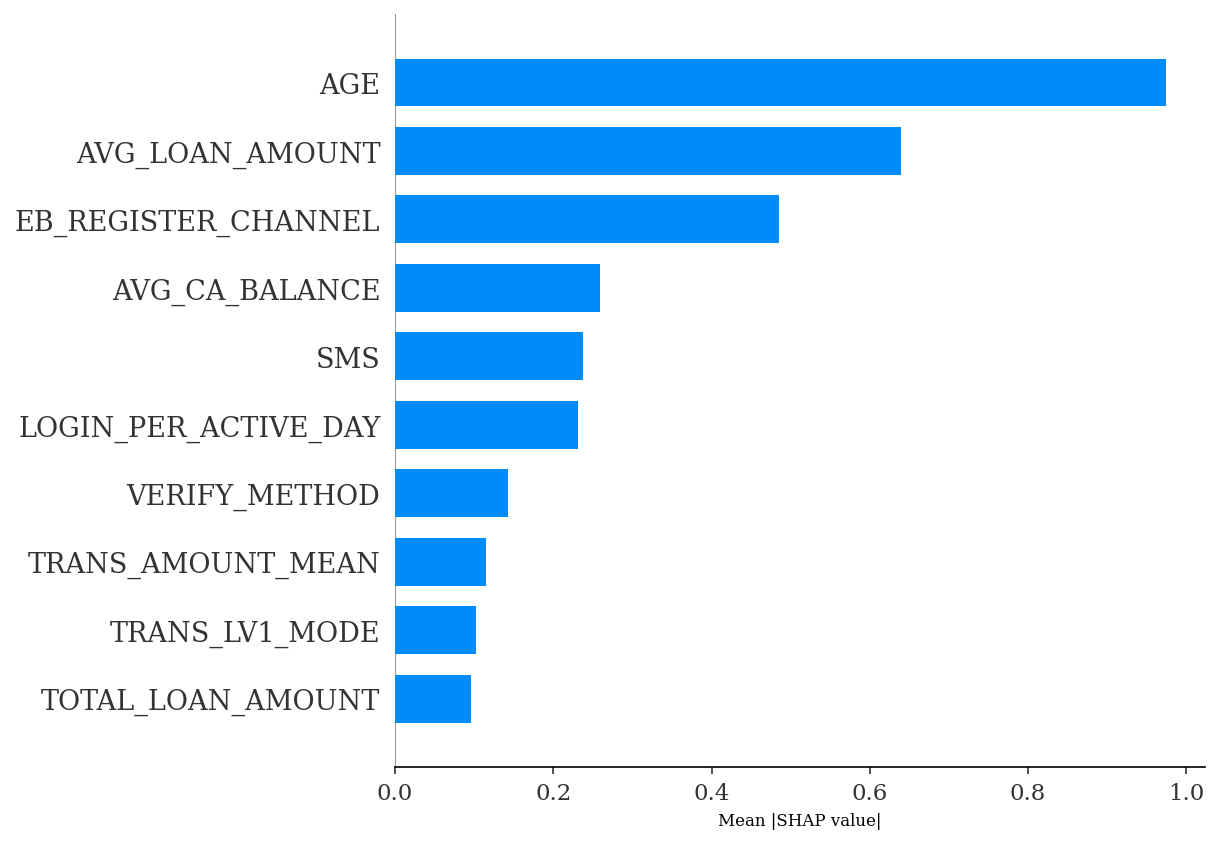


Saving SHAP beeswarm plot:
/content/drive/MyDrive/Fintect/landmark_30d_training_results/full_metrics_shap/Fig_Landmark30D_SHAP_Beeswarm_600dpi.png


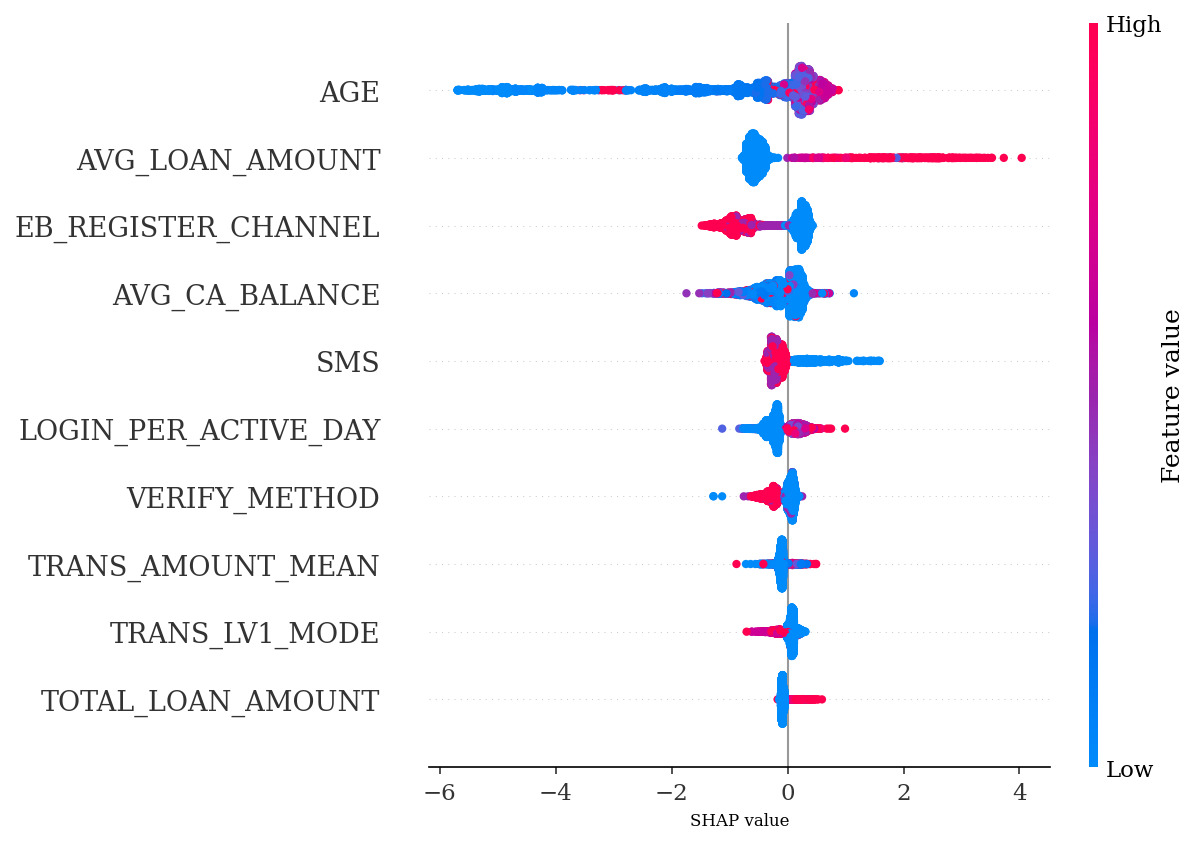


Saving COUNT_CA_ACCT dependence plot:
/content/drive/MyDrive/Fintect/landmark_30d_training_results/full_metrics_shap/Fig_Landmark30D_COUNT_CA_ACCT_Dependence_600dpi.png


<Figure size 525x450 with 0 Axes>

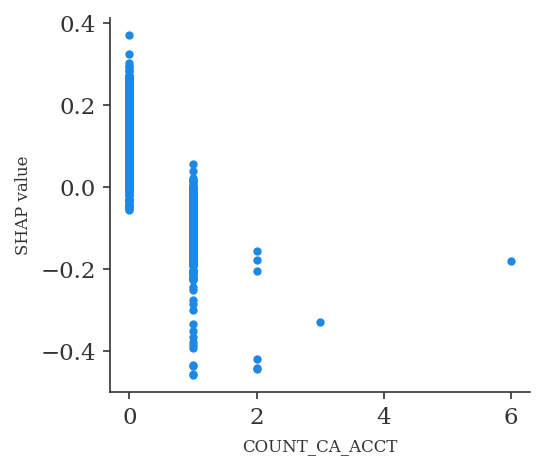


LANDMARK 30-DAY XGBOOST + ROS + SHAP COMPLETED

Performance table:
                  Metric      Test set 5-fold CV (mean ± SD)
                     AUC         0.894       0.8827 ± 0.0068
            KS statistic         0.623       0.6037 ± 0.0116
                  Recall         0.766       0.7369 ± 0.0169
               Precision         0.257       0.2539 ± 0.0062
                F1-score         0.385       0.3777 ± 0.0078
                Accuracy         0.841       0.8418 ± 0.0044
             Brier score         0.116       0.1174 ± 0.0019
 Precision@10% / Lift@D1 0.388 / 5.952                     —
             Capture@10%         0.595                     —
Precision@20% / Lift@20% 0.252 / 3.869                     —
             Capture@20%         0.774                     —
Precision@30% / Lift@30% 0.190 / 2.916                     —
             Capture@30%         0.875                     —

Top five SHAP features:
 RANK             FEATURE  MEAN_ABS_SHAP  MEAN_SIGNED

In [ ]:
# ============================================================
# ETB LANDMARK 30-DAY
# XGBOOST + RANDOM OVERSAMPLING + SHAP
#
# Outputs:
#   1. Five-fold cross-validation metrics
#   2. Holdout test metrics
#   3. Ranking metrics at Top 10%, 20%, 30%
#   4. Publication-style performance table
#   5. SHAP global importance
#   6. SHAP bar plot
#   7. SHAP beeswarm plot
#   8. COUNT_CA_ACCT dependence plot
#
# GOOGLE COLAB — COPY AND RUN DIRECTLY
# ============================================================

# Bỏ dấu # ở dòng dưới nếu Colab chưa có thư viện:
# !pip install -q shap xgboost imbalanced-learn openpyxl

import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE_ROOT = "/content/drive/MyDrive"

if not Path(MYDRIVE_ROOT).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE_ROOT}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 30

INPUT_FILE = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "final_landmark_30d",
    "final_dataset_landmark_30d_no_auto_job.csv"
)

OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "landmark_30d_training_results",
    "full_metrics_shap"
)

# Luôn tạo đầy đủ thư mục cha và thư mục output.
Path(OUTPUT_DIR).mkdir(
    parents=True,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_30D"

TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 42
MODEL_RANDOM_STATE = 42

DECISION_THRESHOLD = 0.50

SHAP_SAMPLE_SIZE = 5000
MAX_SHAP_DISPLAY = 10

MODEL_NAME = "XGBoost + RandomOverSampling (ROS)"

print("=" * 80)
print("LANDMARK 30-DAY CONFIGURATION")
print("=" * 80)

print("\nInput file:")
print(INPUT_FILE)

print("\nInput exists:")
print(Path(INPUT_FILE).is_file())

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nOutput directory exists:")
print(Path(OUTPUT_DIR).is_dir())

if not Path(INPUT_FILE).is_file():
    raise FileNotFoundError(
        "Không tìm thấy file đầu vào:\n"
        f"{INPUT_FILE}\n\n"
        "Hãy kiểm tra lại tên thư mục hoặc chạy bước tạo "
        "final dataset Landmark 30 ngày trước."
    )


# ============================================================
# 3. EXCLUDED COLUMNS
# ============================================================

EXCLUDE_COLS = [
    ID_COL,
    TARGET_COL,

    "COUNT_CREDITCARD",
    "TOTAL_CARD",
    "RAW_TARGET",
    "TARGET",
    "TARGET_MONTH",

    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",

    "RELATIONSHIP_START_DATE",
    "LANDMARK_DATE",
    "FEATURE_CUTOFF_DATE",
    "CLIENT_CREATE_DATE",

    "HAS_30D_FOLLOWUP",
    "EARLY_CARD_30D",

    # Loại thêm tên cột của các cửa sổ khác nếu vô tình còn trong file.
    "HAS_60D_FOLLOWUP",
    "EARLY_CARD_60D",
    "HAS_90D_FOLLOWUP",
    "EARLY_CARD_90D",
    "HAS_180D_FOLLOWUP",
    "EARLY_CARD_180D",

    "TENURE_AT_CUTOFF",
    "TENURE_DAYS_AT_TARGET"
]


# ============================================================
# 4. IEEE FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def ensure_output_dir():
    """
    Tạo lại thư mục output nếu thư mục bị mất hoặc Drive
    vừa được kết nối lại.
    """
    Path(OUTPUT_DIR).mkdir(
        parents=True,
        exist_ok=True
    )

    if not Path(OUTPUT_DIR).is_dir():
        raise RuntimeError(
            "Không thể tạo thư mục output:\n"
            f"{OUTPUT_DIR}"
        )


def get_xgb_model():
    """
    Tạo XGBoost với cùng cấu hình cho CV và mô hình cuối.
    """
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        max_bin=256,
        random_state=MODEL_RANDOM_STATE,
        n_jobs=2
    )


def standardize_customer_id(series):
    """
    Chuẩn hóa CUSTOMER_NUMBER thành chuỗi.
    """
    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [
        "",
        "NAN",
        "<NA>",
        "NONE",
        "NULL"
    ]

    return result.mask(
        result.str.upper().isin(invalid_values),
        pd.NA
    )


def require_columns(
    dataframe,
    required_columns,
    table_name
):
    """
    Kiểm tra các cột bắt buộc.
    """
    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{table_name} thiếu các cột:\n"
            f"{missing_columns}\n\n"
            f"Các cột hiện có:\n"
            f"{dataframe.columns.tolist()}"
        )


def fit_preprocess(
    X_train_raw,
    X_valid_raw,
    categorical_columns
):
    """
    Fit preprocessing chỉ trên training subset.

    - Ordinal encoding cho biến phân loại.
    - Unknown category = -1.
    - Median imputation cho tất cả feature sau encoding.
    """
    X_train_work = X_train_raw.copy()
    X_valid_work = X_valid_raw.copy()

    encoder = None

    if categorical_columns:

        for column in categorical_columns:

            X_train_work[column] = (
                X_train_work[column]
                .astype("string")
                .fillna("UNKNOWN")
            )

            X_valid_work[column] = (
                X_valid_work[column]
                .astype("string")
                .fillna("UNKNOWN")
            )

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
            dtype=np.float32
        )

        X_train_work[categorical_columns] = (
            encoder.fit_transform(
                X_train_work[categorical_columns]
            )
        )

        X_valid_work[categorical_columns] = (
            encoder.transform(
                X_valid_work[categorical_columns]
            )
        )

    for column in X_train_work.columns:

        X_train_work[column] = pd.to_numeric(
            X_train_work[column],
            errors="coerce"
        )

        X_valid_work[column] = pd.to_numeric(
            X_valid_work[column],
            errors="coerce"
        )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_processed = (
        imputer
        .fit_transform(X_train_work)
        .astype(np.float32)
    )

    X_valid_processed = (
        imputer
        .transform(X_valid_work)
        .astype(np.float32)
    )

    return (
        X_train_processed,
        X_valid_processed,
        imputer,
        encoder
    )


def calculate_ks(
    y_true,
    y_probability
):
    """
    Tính Kolmogorov-Smirnov statistic.
    """
    fpr, tpr, _ = roc_curve(
        y_true,
        y_probability
    )

    return float(
        np.max(tpr - fpr)
    )


def calculate_ranking_metrics(
    y_true,
    y_probability,
    top_rates=(0.10, 0.20, 0.30)
):
    """
    Tính Precision, Lift và Capture Rate tại Top K%.
    """
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    n_customers = len(ranking)
    base_rate = float(ranking["Y_TRUE"].mean())
    total_positives = int(ranking["Y_TRUE"].sum())

    rows = []

    for rate in top_rates:

        top_n = max(
            1,
            int(np.ceil(n_customers * rate))
        )

        top_group = ranking.iloc[:top_n]

        precision_at_k = float(
            top_group["Y_TRUE"].mean()
        )

        captured_positives = int(
            top_group["Y_TRUE"].sum()
        )

        lift_at_k = (
            precision_at_k / base_rate
            if base_rate > 0
            else np.nan
        )

        capture_rate = (
            captured_positives / total_positives
            if total_positives > 0
            else np.nan
        )

        rows.append({
            "TOP_K": f"Top {int(rate * 100)}%",
            "TOP_RATE": float(rate),
            "CUSTOMERS": int(top_n),
            "PRECISION": precision_at_k,
            "LIFT": lift_at_k,
            "CAPTURED_POSITIVES": captured_positives,
            "CAPTURE_RATE": capture_rate
        })

    return pd.DataFrame(rows)


def create_decile_table(
    y_true,
    y_probability
):
    """
    Tạo bảng decile D1–D10.
    """
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking["DECILE"] = pd.qcut(
        np.arange(len(ranking)),
        q=10,
        labels=[
            f"D{i}"
            for i in range(1, 11)
        ]
    )

    result = (
        ranking
        .groupby(
            "DECILE",
            observed=False
        )
        .agg(
            CUSTOMERS=("Y_TRUE", "count"),
            POSITIVES=("Y_TRUE", "sum"),
            ADOPTION_RATE=("Y_TRUE", "mean"),
            AVG_PRED_PROB=("Y_PROB", "mean")
        )
        .reset_index()
    )

    base_rate = float(
        ranking["Y_TRUE"].mean()
    )

    result["LIFT"] = (
        result["ADOPTION_RATE"] / base_rate
        if base_rate > 0
        else np.nan
    )

    return result


def get_ranking_row(
    ranking_table,
    top_rate
):
    """
    Lấy hàng ranking tương ứng với TOP_RATE.
    """
    matched_rows = ranking_table.loc[
        np.isclose(
            ranking_table["TOP_RATE"],
            top_rate,
            atol=1e-8
        )
    ]

    if matched_rows.empty:
        raise ValueError(
            f"Không tìm thấy ranking metric cho "
            f"Top {int(top_rate * 100)}%."
        )

    return matched_rows.iloc[0]


def format_test_metric(
    value,
    decimals=3
):
    return f"{float(value):.{decimals}f}"


def format_cv_metric(
    values,
    decimals=4
):
    mean_value = float(values.mean())
    std_value = float(values.std(ddof=1))

    return (
        f"{mean_value:.{decimals}f} ± "
        f"{std_value:.{decimals}f}"
    )


# ============================================================
# 6. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

require_columns(
    df,
    [
        ID_COL,
        TARGET_COL
    ],
    "Landmark 30-day dataset"
)

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        "TARGET_30D phải chỉ gồm 0 và 1."
    )

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(np.int8)
)

duplicate_count = int(
    df[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_count > 0:
    raise ValueError(
        f"Có {duplicate_count:,} khách hàng bị trùng."
    )

df = df.replace(
    [
        "",
        " ",
        "NA",
        "N/A",
        "na",
        "null",
        "NULL",
        "None",
        "none"
    ],
    np.nan
)

df = (
    df
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("DATASET")
print("=" * 80)

print("Shape:", df.shape)

print("\nTarget distribution:")
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{df[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 7. PREPARE FEATURES
# ============================================================

feature_cols = [
    column
    for column in df.columns
    if column not in EXCLUDE_COLS
]

if not feature_cols:
    raise ValueError(
        "Không còn feature nào sau khi loại EXCLUDE_COLS."
    )

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()
customer_ids = df[ID_COL].copy()

# Nhận diện cột text nhưng thực chất là numeric.
for column in X.columns:

    is_text = (
        pd.api.types.is_object_dtype(X[column])
        or pd.api.types.is_string_dtype(X[column])
        or isinstance(
            X[column].dtype,
            pd.CategoricalDtype
        )
    )

    if is_text:

        converted = pd.to_numeric(
            X[column],
            errors="coerce"
        )

        original_non_null = int(
            X[column].notna().sum()
        )

        converted_non_null = int(
            converted.notna().sum()
        )

        numeric_ratio = (
            converted_non_null / original_non_null
            if original_non_null > 0
            else 0
        )

        if numeric_ratio >= 0.80:
            X[column] = converted
        else:
            X[column] = X[column].astype("string")

categorical_columns = (
    X.select_dtypes(
        include=[
            "object",
            "string",
            "category"
        ]
    )
    .columns
    .tolist()
)

print(
    "\nNumber of features:",
    len(feature_cols)
)

print("\nFeature list:")

for index, feature in enumerate(
    feature_cols,
    start=1
):
    print(f"{index:02d}. {feature}")

print("\nCategorical columns:")
print(categorical_columns)


# ============================================================
# 8. TRAIN–TEST SPLIT
# ============================================================

all_indices = np.arange(len(df))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SPLIT_RANDOM_STATE
)

X_train = (
    X.iloc[train_indices]
    .reset_index(drop=True)
)

X_test = (
    X.iloc[test_indices]
    .reset_index(drop=True)
)

y_train = (
    y.iloc[train_indices]
    .reset_index(drop=True)
)

y_test = (
    y.iloc[test_indices]
    .reset_index(drop=True)
)

test_ids = (
    customer_ids.iloc[test_indices]
    .reset_index(drop=True)
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print(
    "\nTrain positive rate:",
    f"{y_train.mean() * 100:.4f}%"
)

print(
    "Test positive rate:",
    f"{y_test.mean() * 100:.4f}%"
)


# ============================================================
# 9. FIVE-FOLD CROSS-VALIDATION
# ============================================================

stratified_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=MODEL_RANDOM_STATE
)

cv_rows = []

for fold, (
    fold_train_indices,
    fold_valid_indices
) in enumerate(
    stratified_cv.split(
        X_train,
        y_train
    ),
    start=1
):

    print(
        f"\nRunning fold {fold}/{N_SPLITS}..."
    )

    X_fold_train = (
        X_train.iloc[fold_train_indices]
        .copy()
    )

    X_fold_valid = (
        X_train.iloc[fold_valid_indices]
        .copy()
    )

    y_fold_train = (
        y_train.iloc[fold_train_indices]
        .copy()
    )

    y_fold_valid = (
        y_train.iloc[fold_valid_indices]
        .copy()
    )

    (
        X_fold_train_processed,
        X_fold_valid_processed,
        _,
        _
    ) = fit_preprocess(
        X_fold_train,
        X_fold_valid,
        categorical_columns
    )

    ros = RandomOverSampler(
        random_state=MODEL_RANDOM_STATE
    )

    X_fold_ros, y_fold_ros = ros.fit_resample(
        X_fold_train_processed,
        y_fold_train.to_numpy()
    )

    fold_model = get_xgb_model()

    fold_model.fit(
        X_fold_ros,
        y_fold_ros
    )

    y_valid_probability = (
        fold_model
        .predict_proba(
            X_fold_valid_processed
        )[:, 1]
    )

    y_valid_prediction = (
        y_valid_probability
        >= DECISION_THRESHOLD
    ).astype(np.int8)

    fold_result = {
        "FOLD": fold,
        "AUC": roc_auc_score(
            y_fold_valid,
            y_valid_probability
        ),
        "KS": calculate_ks(
            y_fold_valid,
            y_valid_probability
        ),
        "RECALL": recall_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "PRECISION": precision_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_fold_valid,
            y_valid_prediction
        ),
        "BRIER": brier_score_loss(
            y_fold_valid,
            y_valid_probability
        )
    }

    cv_rows.append(fold_result)

    print(
        f"AUC={fold_result['AUC']:.4f} | "
        f"KS={fold_result['KS']:.4f} | "
        f"Recall={fold_result['RECALL']:.4f} | "
        f"Precision={fold_result['PRECISION']:.4f} | "
        f"F1={fold_result['F1']:.4f}"
    )

    del fold_model
    del ros
    del X_fold_train_processed
    del X_fold_valid_processed
    del X_fold_ros
    del y_fold_ros

    gc.collect()

cv_results = pd.DataFrame(cv_rows)

cv_metric_columns = [
    "AUC",
    "KS",
    "RECALL",
    "PRECISION",
    "F1",
    "ACCURACY",
    "BRIER"
]

cv_summary = pd.DataFrame([
    {
        "METRIC": metric,
        "MEAN": float(
            cv_results[metric].mean()
        ),
        "STD": float(
            cv_results[metric].std(ddof=1)
        ),
        "MEAN_PLUS_MINUS_SD": (
            f"{cv_results[metric].mean():.4f} ± "
            f"{cv_results[metric].std(ddof=1):.4f}"
        )
    }
    for metric in cv_metric_columns
])

print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

print(
    cv_summary[
        [
            "METRIC",
            "MEAN_PLUS_MINUS_SD"
        ]
    ].to_string(index=False)
)


# ============================================================
# 10. PREPROCESS FULL TRAIN AND TEST
# ============================================================

(
    X_train_processed,
    X_test_processed,
    final_imputer,
    final_encoder
) = fit_preprocess(
    X_train,
    X_test,
    categorical_columns
)


# ============================================================
# 11. RANDOM OVERSAMPLING
# ============================================================

final_ros = RandomOverSampler(
    random_state=MODEL_RANDOM_STATE
)

X_train_ros, y_train_ros = final_ros.fit_resample(
    X_train_processed,
    y_train.to_numpy()
)

print("\n" + "=" * 80)
print("RANDOM OVERSAMPLING")
print("=" * 80)

print("Before ROS:", X_train_processed.shape)
print("After ROS :", X_train_ros.shape)

print("\nClass distribution after ROS:")

print(
    pd.Series(y_train_ros)
    .value_counts()
    .sort_index()
)


# ============================================================
# 12. TRAIN FINAL MODEL
# ============================================================

print("\nTraining final model...")

final_model = get_xgb_model()

final_model.fit(
    X_train_ros,
    y_train_ros
)

print("Final model training completed.")


# ============================================================
# 13. TEST PREDICTIONS AND METRICS
# ============================================================

y_test_probability = (
    final_model
    .predict_proba(
        X_test_processed
    )[:, 1]
)

y_test_prediction = (
    y_test_probability
    >= DECISION_THRESHOLD
).astype(np.int8)

test_auc = roc_auc_score(
    y_test,
    y_test_probability
)

test_ks = calculate_ks(
    y_test,
    y_test_probability
)

test_recall = recall_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_precision = precision_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    y_test_prediction
)

test_brier = brier_score_loss(
    y_test,
    y_test_probability
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_prediction,
    labels=[0, 1]
).ravel()

print("\n" + "=" * 80)
print("TEST RESULTS")
print("=" * 80)

print(f"AUC       : {test_auc:.6f}")
print(f"KS        : {test_ks:.6f}")
print(f"Recall    : {test_recall:.6f}")
print(f"Precision : {test_precision:.6f}")
print(f"F1        : {test_f1:.6f}")
print(f"Accuracy  : {test_accuracy:.6f}")
print(f"Brier     : {test_brier:.6f}")

print("\nConfusion matrix:")

print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nClassification report:")

print(
    classification_report(
        y_test,
        y_test_prediction,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 14. RANKING METRICS
# ============================================================

ranking_results = calculate_ranking_metrics(
    y_test,
    y_test_probability
)

decile_table = create_decile_table(
    y_test,
    y_test_probability
)

print("\n" + "=" * 80)
print("RANKING METRICS")
print("=" * 80)

print(
    ranking_results.to_string(index=False)
)

predictions = pd.DataFrame({
    ID_COL: test_ids.to_numpy(),
    "Y_TRUE": y_test.to_numpy(),
    "Y_PROB": np.asarray(y_test_probability),
    "Y_PRED": np.asarray(y_test_prediction)
})

top10 = get_ranking_row(
    ranking_results,
    0.10
)

top20 = get_ranking_row(
    ranking_results,
    0.20
)

top30 = get_ranking_row(
    ranking_results,
    0.30
)


# ============================================================
# 15. PUBLICATION-STYLE PERFORMANCE TABLE
# ============================================================

performance_table = pd.DataFrame([
    {
        "Metric": "AUC",
        "Test set": format_test_metric(test_auc),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["AUC"]
        )
    },
    {
        "Metric": "KS statistic",
        "Test set": format_test_metric(test_ks),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["KS"]
        )
    },
    {
        "Metric": "Recall",
        "Test set": format_test_metric(test_recall),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["RECALL"]
        )
    },
    {
        "Metric": "Precision",
        "Test set": format_test_metric(test_precision),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["PRECISION"]
        )
    },
    {
        "Metric": "F1-score",
        "Test set": format_test_metric(test_f1),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["F1"]
        )
    },
    {
        "Metric": "Accuracy",
        "Test set": format_test_metric(test_accuracy),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["ACCURACY"]
        )
    },
    {
        "Metric": "Brier score",
        "Test set": format_test_metric(test_brier),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["BRIER"]
        )
    },
    {
        "Metric": "Precision@10% / Lift@D1",
        "Test set": (
            f"{float(top10['PRECISION']):.3f} / "
            f"{float(top10['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@10%",
        "Test set": format_test_metric(
            top10["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Precision@20% / Lift@20%",
        "Test set": (
            f"{float(top20['PRECISION']):.3f} / "
            f"{float(top20['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@20%",
        "Test set": format_test_metric(
            top20["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Precision@30% / Lift@30%",
        "Test set": (
            f"{float(top30['PRECISION']):.3f} / "
            f"{float(top30['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@30%",
        "Test set": format_test_metric(
            top30["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    }
])

print("\n" + "=" * 95)
print("PUBLICATION-STYLE PERFORMANCE TABLE")
print("=" * 95)

print(
    performance_table.to_string(index=False)
)


# ============================================================
# 16. PREPARE SHAP SAMPLE
# ============================================================

shap_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test_processed)
)

random_generator = np.random.default_rng(
    MODEL_RANDOM_STATE
)

shap_indices = random_generator.choice(
    len(X_test_processed),
    size=shap_sample_size,
    replace=False
)

X_shap = pd.DataFrame(
    X_test_processed[shap_indices],
    columns=feature_cols
)

print("\n" + "=" * 80)
print("SHAP ANALYSIS")
print("=" * 80)

print("SHAP sample size:", shap_sample_size)
print("SHAP input shape:", X_shap.shape)


# ============================================================
# 17. CALCULATE SHAP VALUES
# ============================================================

print("\nComputing SHAP values...")

shap_explainer = shap.TreeExplainer(
    final_model
)

shap_values_raw = shap_explainer.shap_values(
    X_shap
)

if isinstance(shap_values_raw, list):
    shap_values = np.asarray(
        shap_values_raw[-1]
    )
else:
    shap_values = np.asarray(
        shap_values_raw
    )

# Một số phiên bản SHAP trả về:
# (samples, features, classes)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]

if shap_values.shape != X_shap.shape:
    raise ValueError(
        "SHAP shape không khớp dữ liệu:\n"
        f"SHAP shape: {shap_values.shape}\n"
        f"X_SHAP shape: {X_shap.shape}"
    )

if not np.isfinite(shap_values).all():
    raise ValueError(
        "SHAP values có NaN hoặc infinity."
    )

print("SHAP values shape:", shap_values.shape)


# ============================================================
# 18. SHAP GLOBAL IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "FEATURE": feature_cols,
    "MEAN_ABS_SHAP": np.abs(
        shap_values
    ).mean(axis=0),
    "MEAN_SIGNED_SHAP": shap_values.mean(
        axis=0
    )
})

shap_importance = (
    shap_importance
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.insert(
    0,
    "RANK",
    np.arange(
        1,
        len(shap_importance) + 1
    )
)

top5_shap = (
    shap_importance
    .head(5)
    .copy()
)

count_ca_result = shap_importance.loc[
    shap_importance["FEATURE"]
    .astype(str)
    .str.upper()
    .eq("COUNT_CA_ACCT")
]

if not count_ca_result.empty:

    count_ca_rank = int(
        count_ca_result.iloc[0]["RANK"]
    )

    count_ca_mean_abs_shap = float(
        count_ca_result.iloc[0][
            "MEAN_ABS_SHAP"
        ]
    )

else:
    count_ca_rank = None
    count_ca_mean_abs_shap = None

print("\nTop 10 SHAP features:")

print(
    shap_importance
    .head(10)
    .to_string(index=False)
)

print("\nTop five SHAP features:")

print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ].to_string(index=False)
)

print("\nCOUNT_CA_ACCT SHAP rank:")
print(count_ca_rank)

print("\nCOUNT_CA_ACCT mean absolute SHAP:")
print(count_ca_mean_abs_shap)


# ============================================================
# 19. SHAP BAR PLOT — IEEE SINGLE COLUMN
# ============================================================

ensure_output_dir()

shap_bar_png = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark30D_SHAP_Bar_600dpi.png"
)

shap_bar_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark30D_SHAP_Bar.pdf"
)

plt.figure(
    figsize=(3.5, 3.0)
)

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=MAX_SHAP_DISPLAY,
    show=False
)

plt.xlabel(
    "Mean |SHAP value|",
    fontsize=8
)

plt.tight_layout(
    pad=0.3
)

print("\nSaving SHAP bar plot:")
print(shap_bar_png)

plt.savefig(
    shap_bar_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    shap_bar_pdf,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 20. SHAP BEESWARM — IEEE SINGLE COLUMN
# ============================================================

ensure_output_dir()

shap_beeswarm_png = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark30D_SHAP_Beeswarm_600dpi.png"
)

shap_beeswarm_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark30D_SHAP_Beeswarm.pdf"
)

plt.figure(
    figsize=(3.5, 3.4)
)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=MAX_SHAP_DISPLAY,
    show=False
)

plt.xlabel(
    "SHAP value",
    fontsize=8
)

plt.tight_layout(
    pad=0.3
)

print("\nSaving SHAP beeswarm plot:")
print(shap_beeswarm_png)

plt.savefig(
    shap_beeswarm_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    shap_beeswarm_pdf,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 21. COUNT_CA_ACCT DEPENDENCE PLOT
# ============================================================

count_ca_png = None
count_ca_pdf = None

if "COUNT_CA_ACCT" in feature_cols:

    ensure_output_dir()

    count_ca_png = os.path.join(
        OUTPUT_DIR,
        "Fig_Landmark30D_COUNT_CA_ACCT_Dependence_600dpi.png"
    )

    count_ca_pdf = os.path.join(
        OUTPUT_DIR,
        "Fig_Landmark30D_COUNT_CA_ACCT_Dependence.pdf"
    )

    plt.figure(
        figsize=(3.5, 3.0)
    )

    shap.dependence_plot(
        "COUNT_CA_ACCT",
        shap_values,
        X_shap,
        interaction_index=None,
        show=False
    )

    plt.gcf().set_size_inches(
        3.5,
        3.0
    )

    plt.xlabel(
        "COUNT_CA_ACCT",
        fontsize=8
    )

    plt.ylabel(
        "SHAP value",
        fontsize=8
    )

    plt.tight_layout(
        pad=0.3
    )

    print("\nSaving COUNT_CA_ACCT dependence plot:")
    print(count_ca_png)

    plt.savefig(
        count_ca_png,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.savefig(
        count_ca_pdf,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
    plt.close()

else:
    print(
        "\nCOUNT_CA_ACCT không có trong feature list; "
        "bỏ qua dependence plot."
    )


# ============================================================
# 22. COMPLETE MACHINE-READABLE RESULT TABLE
# ============================================================

final_results = pd.DataFrame([{
    "MODEL": MODEL_NAME,
    "LANDMARK_DAYS": LANDMARK_DAYS,

    "N_CUSTOMERS": len(df),
    "N_TRAIN": len(X_train),
    "N_TEST": len(X_test),
    "N_FEATURES": len(feature_cols),

    "BASE_RATE": float(y.mean()),

    "CV_AUC_MEAN": float(
        cv_results["AUC"].mean()
    ),
    "CV_AUC_STD": float(
        cv_results["AUC"].std(ddof=1)
    ),

    "CV_KS_MEAN": float(
        cv_results["KS"].mean()
    ),
    "CV_KS_STD": float(
        cv_results["KS"].std(ddof=1)
    ),

    "CV_RECALL_MEAN": float(
        cv_results["RECALL"].mean()
    ),
    "CV_RECALL_STD": float(
        cv_results["RECALL"].std(ddof=1)
    ),

    "CV_PRECISION_MEAN": float(
        cv_results["PRECISION"].mean()
    ),
    "CV_PRECISION_STD": float(
        cv_results["PRECISION"].std(ddof=1)
    ),

    "CV_F1_MEAN": float(
        cv_results["F1"].mean()
    ),
    "CV_F1_STD": float(
        cv_results["F1"].std(ddof=1)
    ),

    "CV_ACCURACY_MEAN": float(
        cv_results["ACCURACY"].mean()
    ),
    "CV_ACCURACY_STD": float(
        cv_results["ACCURACY"].std(ddof=1)
    ),

    "CV_BRIER_MEAN": float(
        cv_results["BRIER"].mean()
    ),
    "CV_BRIER_STD": float(
        cv_results["BRIER"].std(ddof=1)
    ),

    "TEST_AUC": float(test_auc),
    "TEST_KS": float(test_ks),
    "TEST_RECALL": float(test_recall),
    "TEST_PRECISION": float(test_precision),
    "TEST_F1": float(test_f1),
    "TEST_ACCURACY": float(test_accuracy),
    "TEST_BRIER": float(test_brier),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "PRECISION_AT_10": float(
        top10["PRECISION"]
    ),
    "LIFT_AT_10": float(
        top10["LIFT"]
    ),
    "CAPTURE_RATE_AT_10": float(
        top10["CAPTURE_RATE"]
    ),

    "PRECISION_AT_20": float(
        top20["PRECISION"]
    ),
    "LIFT_AT_20": float(
        top20["LIFT"]
    ),
    "CAPTURE_RATE_AT_20": float(
        top20["CAPTURE_RATE"]
    ),

    "PRECISION_AT_30": float(
        top30["PRECISION"]
    ),
    "LIFT_AT_30": float(
        top30["LIFT"]
    ),
    "CAPTURE_RATE_AT_30": float(
        top30["CAPTURE_RATE"]
    ),

    "TOP_SHAP_FEATURE": str(
        top5_shap.iloc[0]["FEATURE"]
    ),

    "COUNT_CA_ACCT_SHAP_RANK": (
        count_ca_rank
    ),

    "COUNT_CA_ACCT_MEAN_ABS_SHAP": (
        count_ca_mean_abs_shap
    )
}])


# ============================================================
# 23. SAVE CSV OUTPUTS
# ============================================================

ensure_output_dir()

final_results_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_final_results.csv"
)

cv_results_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_cross_validation_results.csv"
)

cv_summary_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_cv_mean_sd.csv"
)

ranking_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_ranking_metrics.csv"
)

decile_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_decile_table.csv"
)

predictions_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_test_predictions.csv"
)

performance_table_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_publication_performance_table.csv"
)

shap_importance_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_shap_global_importance.csv"
)

top5_shap_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_shap_top5.csv"
)

final_results.to_csv(
    final_results_file,
    index=False,
    encoding="utf-8-sig"
)

cv_results.to_csv(
    cv_results_file,
    index=False,
    encoding="utf-8-sig"
)

cv_summary.to_csv(
    cv_summary_file,
    index=False,
    encoding="utf-8-sig"
)

ranking_results.to_csv(
    ranking_file,
    index=False,
    encoding="utf-8-sig"
)

decile_table.to_csv(
    decile_file,
    index=False,
    encoding="utf-8-sig"
)

predictions.to_csv(
    predictions_file,
    index=False,
    encoding="utf-8-sig"
)

performance_table.to_csv(
    performance_table_file,
    index=False,
    encoding="utf-8-sig"
)

shap_importance.to_csv(
    shap_importance_file,
    index=False,
    encoding="utf-8-sig"
)

top5_shap.to_csv(
    top5_shap_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. SAVE FORMATTED EXCEL
# ============================================================

ensure_output_dir()

excel_file = os.path.join(
    OUTPUT_DIR,
    "landmark30d_xgboost_ros_metrics_shap.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    final_results.to_excel(
        writer,
        sheet_name="Final results",
        index=False
    )

    performance_table.to_excel(
        writer,
        sheet_name="Performance table",
        index=False
    )

    cv_results.to_excel(
        writer,
        sheet_name="Cross validation",
        index=False
    )

    cv_summary.to_excel(
        writer,
        sheet_name="CV mean SD",
        index=False
    )

    ranking_results.to_excel(
        writer,
        sheet_name="Ranking",
        index=False
    )

    decile_table.to_excel(
        writer,
        sheet_name="Deciles",
        index=False
    )

    predictions.to_excel(
        writer,
        sheet_name="Test predictions",
        index=False
    )

    shap_importance.to_excel(
        writer,
        sheet_name="SHAP importance",
        index=False
    )

    top5_shap.to_excel(
        writer,
        sheet_name="SHAP top 5",
        index=False
    )

    performance_sheet = writer.sheets[
        "Performance table"
    ]

    performance_sheet.freeze_panes = "A2"

    performance_sheet.column_dimensions["A"].width = 32
    performance_sheet.column_dimensions["B"].width = 20
    performance_sheet.column_dimensions["C"].width = 28

    for cell in performance_sheet[1]:

        cell.font = cell.font.copy(
            bold=True
        )

        cell.alignment = cell.alignment.copy(
            horizontal="center",
            vertical="center"
        )

    for row in performance_sheet.iter_rows(
        min_row=2,
        max_row=performance_sheet.max_row,
        min_col=2,
        max_col=3
    ):

        for cell in row:

            cell.alignment = cell.alignment.copy(
                horizontal="center",
                vertical="center"
            )


# ============================================================
# 25. FINAL REPORT
# ============================================================

print("\n" + "=" * 95)
print("LANDMARK 30-DAY XGBOOST + ROS + SHAP COMPLETED")
print("=" * 95)

print("\nPerformance table:")

print(
    performance_table.to_string(index=False)
)

print("\nTop five SHAP features:")

print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ].to_string(index=False)
)

print("\nCOUNT_CA_ACCT SHAP rank:")
print(count_ca_rank)

print("\nSaved Excel:")
print(excel_file)

print("\nSHAP bar figure:")
print(shap_bar_png)

print("\nSHAP beeswarm figure:")
print(shap_beeswarm_png)

if count_ca_png is not None:
    print("\nCOUNT_CA_ACCT dependence figure:")
    print(count_ca_png)

print("\nSaved output directory:")
print(OUTPUT_DIR)

print("\nOutput directory exists:")
print(Path(OUTPUT_DIR).is_dir())

print("\nAll files currently saved in output directory:")

for saved_file in sorted(
    Path(OUTPUT_DIR).glob("*")
):
    print(saved_file.name)